# PV & Wind Power Curve Modeling

Erick Chauke

Physics-informed and data-driven power curve models for two PV plants and two wind plants, fit
from source power-curve grids (input files, gitignored). Six standalone models: PV1, PV2,
PV-combined, Wind1, Wind2, Wind-combined.

## Setup

Imports and one config cell for the source path and adjustable parameters.

### Imports

Numeric, tabular, plotting, and Excel-reading libraries used throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

### Configuration

File path and adjustable parameters used by every later section.

In [2]:
# Config: file path and adjustable params, kept in one place so the whole notebook (and each
# models/*.py script) can be re-pointed at a new workbook or re-tuned without hunting through code.
DATA_PATH = "data/FPCs.xlsm"

# Spacing between adjacent grid points in the source spreadsheet (how far apart each measured
# value is from its neighbor). These describe the source data's resolution for reference; the
# actual x-axis/y-axis values are read directly from the sheet in the next section, not
# generated from these step sizes.
PV_IRRADIANCE_STEP = 50    # W/m^2
PV_TEMP_STEP = 5           # deg C
WIND_VELOCITY_STEP = 0.5   # m/s
WIND_DIRECTION_STEP = 15   # deg

# Number of folds for k-fold cross-validation: each model is trained on 4/5 of its rows and
# tested on the remaining 1/5, five times over with a different 1/5 held out each time, so every
# row gets used for testing exactly once. This gives a more reliable accuracy estimate than a
# single train/test split. 5 is a standard default that balances that reliability against how
# many times each model has to be refit.
CV_FOLDS = 5

# Installed nameplate capacity per plant, in megawatts, read from each sheet's title cell
# (row 0, col 0), e.g. "Installed Capacity: 75 MW". Used as the color-scale ceiling on the
# response-surface plots and as the threshold for the "does this model predict above capacity"
# checks in the PV sections.
CAPACITY_MW = {
    "PV1": 75.0,
    "PV2": 75.0,
    "Wind1": 102.0,
    "Wind2": 86.6,
}

## Data Loading & Grid Parsing

Each sheet is a 2D power-curve grid, parsed by position (not pandas' auto-detected headers, which the merged/label cells break).

### Grid parsing helper

Positionally slices a sheet into capacity label, x-axis, y-axis, and power grid.

In [3]:
def parse_grid_sheet(path, sheet_name):
    """Positional parse of one FPCs.xlsm-style grid sheet into title, x-axis, y-axis, power grid."""
    df = pd.read_excel(path, sheet_name=sheet_name, header=None, engine="openpyxl")
    capacity_label = df.iloc[0, 0]
    x_axis = df.iloc[1, 2:].astype(float).to_numpy()
    y_axis = df.iloc[2:, 1].astype(float).to_numpy()
    power_grid = df.iloc[2:, 2:].astype(float).to_numpy()
    return capacity_label, x_axis, y_axis, power_grid

### Load all four sheets

Applies the helper to PV1, PV2, Wind1, and Wind2 into one dict keyed by sheet name.

In [4]:
grids = {}
for sheet_name in ["PV1", "PV2", "Wind1", "Wind2"]:
    capacity_label, x_axis, y_axis, power_grid = parse_grid_sheet(DATA_PATH, sheet_name)
    grids[sheet_name] = {
        "capacity_label": capacity_label,
        "x_axis": x_axis,
        "y_axis": y_axis,
        "power_grid": power_grid,
    }

### Sanity check

Confirms shapes and axis ranges for all four parsed grids.

In [5]:
for sheet_name, g in grids.items():
    print(
        sheet_name, "|", g["capacity_label"],
        "| grid shape:", g["power_grid"].shape,
        "| x range:", g["x_axis"].min(), "-", g["x_axis"].max(),
        "| y range:", g["y_axis"].min(), "-", g["y_axis"].max(),
    )

PV1 | Installed Capacity: 75 MW | grid shape: (28, 20) | x range: -10.0 - 85.0 | y range: 0.0 - 1350.0
PV2 | Installed Capacity: 75 MW | grid shape: (28, 20) | x range: -10.0 - 85.0 | y range: 0.0 - 1350.0
Wind1 | Installed Capacity: 102 MW | grid shape: (51, 24) | x range: 15.0 - 360.0 | y range: 0.0 - 25.0
Wind2 | Installed Capacity: 86.6 MW | grid shape: (51, 24) | x range: 15.0 - 360.0 | y range: 0.0 - 25.0


## Exploratory Data Analysis

Raw grid heatmaps, the PV missingness pattern, and the Wind2 negative-value artifact.

### Raw grid heatmaps

Power grid for each of the four sheets, plotted over its native axes.

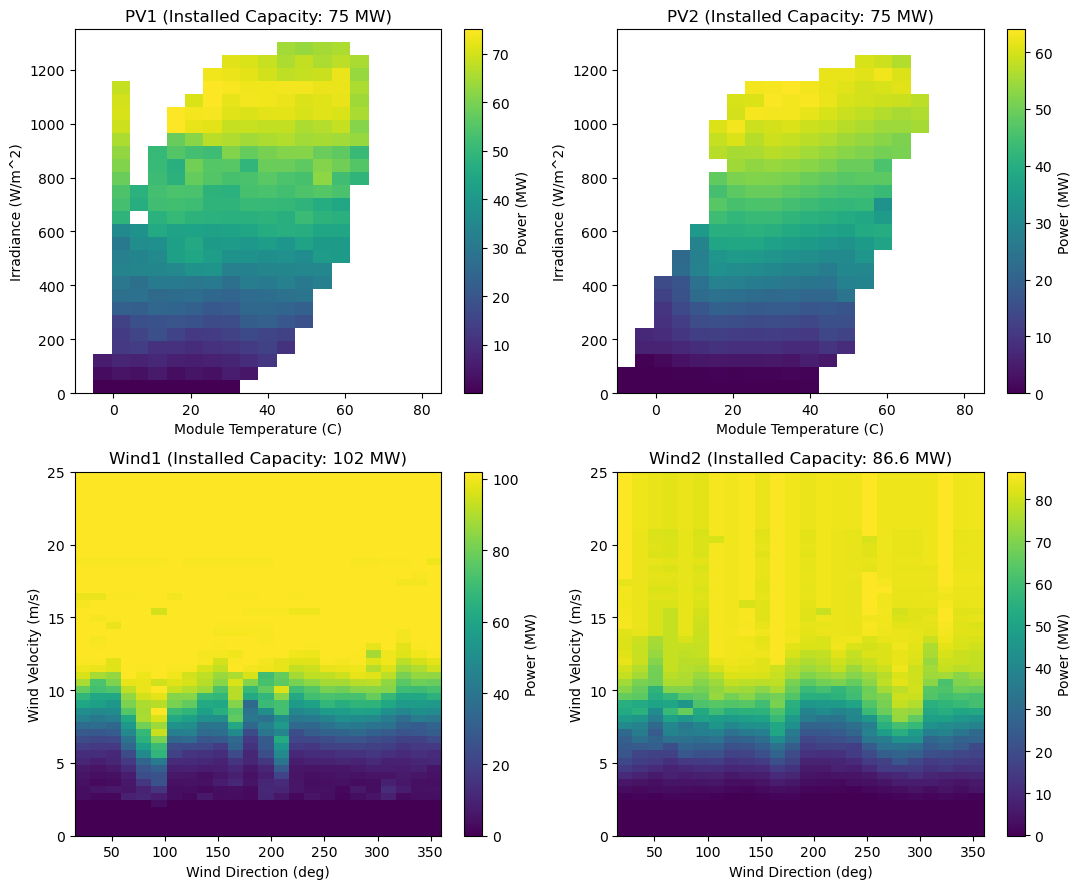

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, sheet_name in zip(axes.flat, ["PV1", "PV2", "Wind1", "Wind2"]):
    g = grids[sheet_name]
    is_pv = sheet_name.startswith("PV")
    im = ax.imshow(
        g["power_grid"], origin="lower", aspect="auto",
        extent=[g["x_axis"].min(), g["x_axis"].max(), g["y_axis"].min(), g["y_axis"].max()],
    )
    ax.set_title(f"{sheet_name} ({g['capacity_label']})")
    ax.set_xlabel("Module Temperature (C)" if is_pv else "Wind Direction (deg)")
    ax.set_ylabel("Irradiance (W/m^2)" if is_pv else "Wind Velocity (m/s)")
    fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs/all_sheets_raw_grids.png", dpi=150)
plt.show()

### PV missingness pattern

Fill rate for PV1 and PV2, checked against the documented values.

In [7]:
for sheet_name in ["PV1", "PV2"]:
    power_grid = grids[sheet_name]["power_grid"]
    fill_rate = 100 * (1 - np.isnan(power_grid).mean())
    print(f"{sheet_name}: {fill_rate:.1f}% filled ({np.isnan(power_grid).sum()} missing cells)")

PV1: 53.2% filled (262 missing cells)
PV2: 47.9% filled (292 missing cells)


### PV missingness heatmap

Where the missing cells fall in (irradiance, module temperature) space, for PV1 and PV2 side by side.

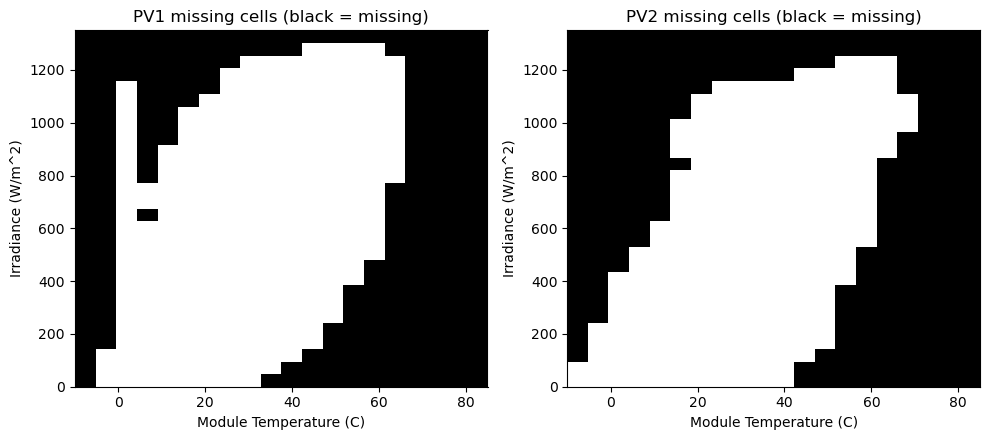

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, sheet_name in zip(axes, ["PV1", "PV2"]):
    g = grids[sheet_name]
    missing_mask = np.isnan(g["power_grid"])
    ax.imshow(
        missing_mask, origin="lower", aspect="auto", cmap="gray_r",
        extent=[g["x_axis"].min(), g["x_axis"].max(), g["y_axis"].min(), g["y_axis"].max()],
    )
    ax.set_title(f"{sheet_name} missing cells (black = missing)")
    ax.set_xlabel("Module Temperature (C)")
    ax.set_ylabel("Irradiance (W/m^2)")
fig.tight_layout()
fig.savefig("outputs/pv1_pv2_missingness.png", dpi=150)
plt.show()

### Wind2 negative-value check

Locate the documented near-zero negative artifact before deciding how to handle it.

In [9]:
wind2_grid = grids["Wind2"]["power_grid"]
wind2_velocity = grids["Wind2"]["y_axis"]
wind2_direction = grids["Wind2"]["x_axis"]

for row, col in np.argwhere(wind2_grid < 0):
    print(
        f"velocity={wind2_velocity[row]} m/s, direction={wind2_direction[col]} deg, "
        f"power={wind2_grid[row, col]:.4f} MW"
    )

velocity=2.5 m/s, direction=240.0 deg, power=-0.0948 MW
velocity=2.5 m/s, direction=255.0 deg, power=-0.0573 MW


### Clip Wind2 artifact

Clip the negative cell(s) to 0 in place; this is measurement noise around zero wind speed, not real negative generation.

In [10]:
# Clip near-zero negative artifact (measurement noise around zero wind speed, not real
# negative generation) -- see the Wind2 negative-value check above for the flagged cell(s).
grids["Wind2"]["power_grid"] = np.clip(wind2_grid, 0.0, None)
print("remaining negative cells:", (grids["Wind2"]["power_grid"] < 0).sum())

remaining negative cells: 0


### Discussion

The raw grids look physically sane: PV1/PV2 power rises with irradiance and eases off with
higher module temperature at fixed irradiance, and both wind plants show the expected S-curve,
cutting in near 3 m/s and flattening at rated capacity (102 MW / 86.6 MW) by around 10-12 m/s,
with no strong dependence on wind direction.

PV1 is 53.2% filled (262 of 560 cells missing), PV2 is 47.9% filled (292 of 560), matching the
documented fill rates. The missingness heatmap shows why: filled cells form a diagonal band
running from (low irradiance, low temperature) to (high irradiance, high temperature). The
missing corners, cold module with high irradiance and hot module with little irradiance, are
combinations that essentially never occur in the field because irradiance is what heats the
module. This is a sampling artifact of physically coupled inputs, not a data quality problem, so
it is left as unsampled space for the models to generalize into rather than something to impute.

The Wind2 check found two near-zero negative cells (-0.095 MW and -0.057 MW), both at 2.5 m/s
(below cut-in), at wind directions 240 and 255 degrees, not the single cell the source
description mentioned. Both are measurement noise around zero, not real negative generation, and
have been clipped to 0 in `grids["Wind2"]["power_grid"]`.

## PV1 Model

Physics formula and ML models for PV1, compared directly, especially in the unsampled region.

### Tidy long format

Reshape the PV1 grid to one row per (irradiance, module temperature) cell, dropping true NaNs.

In [11]:
irradiance_mesh, temp_mesh = np.meshgrid(grids["PV1"]["y_axis"], grids["PV1"]["x_axis"], indexing="ij")
pv1_df = pd.DataFrame({
    "irradiance": irradiance_mesh.ravel(),
    "module_temp": temp_mesh.ravel(),
    "power": grids["PV1"]["power_grid"].ravel(),
})
pv1_df = pv1_df.dropna(subset=["power"]).reset_index(drop=True)

In [12]:
n_rows, n_cols = grids["PV1"]["power_grid"].shape
print(f"PV1: retained {len(pv1_df)} of {n_rows * n_cols} grid cells ({n_rows} irradiance x {n_cols} temperature)")

PV1: retained 298 of 560 grid cells (28 irradiance x 20 temperature)


### Physics formula

Standard linear temperature-coefficient PV model [1]:

$$P = \beta_0 \cdot G + \beta_1 \cdot G \cdot (T_m - 25)$$

where $G$ is irradiance (W/m^2) and $T_m$ is module temperature (C), fit by ordinary least
squares on $[G,\ G(T_m-25)]$ with no intercept.

In [13]:
from sklearn.linear_model import LinearRegression

# Build the two physics-formula features directly from the formula above: G, and G*(Tm-25).
X_pv1 = np.column_stack([pv1_df["irradiance"], pv1_df["irradiance"] * (pv1_df["module_temp"] - 25)])
y_pv1 = pv1_df["power"].to_numpy()

# fit_intercept=False: the formula has no standalone constant term, at zero irradiance the
# model should predict exactly zero power, which is physically correct (no sun, no output).
pv1_physics_model = LinearRegression(fit_intercept=False).fit(X_pv1, y_pv1)
beta0_pv1, beta1_pv1 = pv1_physics_model.coef_

In [14]:
print(f"PV1 physics formula: beta0 = {beta0_pv1:.5f} MW per W/m^2, beta1 = {beta1_pv1:.6f} MW per W/m^2 per degC")

PV1 physics formula: beta0 = 0.06708 MW per W/m^2, beta1 = -0.000124 MW per W/m^2 per degC


### Cross-validation helper

Reusable 5-fold cross-validation evaluator, used by every model in the notebook to report two
plain-language accuracy numbers: **$R^2$** (the fraction of the actual power variation the model
explains, from 0 = no better than always guessing the average, to 1 = perfect) and **RMSE**
(the typical prediction error, in the same units as power, MW, so a lower number is better).

In [15]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

def cv_evaluate(model_fn, X, y, n_splits=CV_FOLDS, random_state=0):
    """5-fold CV R^2/RMSE for a model_fn() -> unfitted estimator, over grid-cell rows."""
    # shuffle=True: draw the 5 folds randomly rather than in the grid's original row order, so
    # each fold is a representative mix of the input space, not e.g. all-low-irradiance rows.
    # random_state=0: fixes the random seed so the exact same folds are drawn every time this
    # notebook is re-run, keeping the reported numbers reproducible.
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, rmse_scores = [], []
    for train_idx, test_idx in kf.split(X):
        model = model_fn().fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        r2_scores.append(r2_score(y[test_idx], pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y[test_idx], pred)))
    return np.array(r2_scores), np.array(rmse_scores)

### Physics formula cross-validation

5-fold CV $R^2$/RMSE for the PV1 physics formula.

In [16]:
r2_pv1_physics, rmse_pv1_physics = cv_evaluate(lambda: LinearRegression(fit_intercept=False), X_pv1, y_pv1)
print(f"PV1 physics formula 5-fold CV: R^2 = {r2_pv1_physics.mean():.4f} +/- {r2_pv1_physics.std():.4f}, "
      f"RMSE = {rmse_pv1_physics.mean():.4f} +/- {rmse_pv1_physics.std():.4f} MW")

PV1 physics formula 5-fold CV: R^2 = 0.9383 +/- 0.0202, RMSE = 5.2506 +/- 0.5614 MW


### Gaussian Process Regression

Primary ML comparison model: well suited to small, smooth 2D data, with predictive uncertainty as a bonus.

In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def make_gp():
    # A Gaussian Process (GP) is a smooth curve-fitting method that also reports how confident
    # it is at each point, not just a single number. Its "kernel" controls how smooth the fitted
    # surface is and how much it trusts nearby points versus treating a wiggle as pure noise:
    #   - ConstantKernel: an overall scale for how much power can vary, searched within the
    #     (1e-2, 1e3) range and fitted automatically to this dataset.
    #   - RBF (Radial Basis Function): the smoothness setting itself, one "length scale" per
    #     input feature (irradiance, module_temp). A short length scale means the model expects
    #     power to change quickly over a small step in that feature; a long one means it expects
    #     a gentler, slower-changing surface. Also fitted automatically, within (1e-2, 1e2).
    #   - WhiteKernel: allows for measurement noise, so the model does not chase every small
    #     wiggle in the grid as if it were a real physical effect.
    # The numbers above are just starting search ranges, sklearn tunes the exact values during
    # .fit() to whatever best matches this specific dataset.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF([1.0, 1.0], (1e-2, 1e2)) + WhiteKernel(1.0, (1e-5, 1e2))
    return make_pipeline(
        StandardScaler(),  # put irradiance and temperature on a comparable numeric scale first,
                            # since the GP compares distances between points across both features
        GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,        # apply the same rescaling to the power values being predicted
            n_restarts_optimizer=3,  # try 3 different starting points when tuning the kernel, to
                                      # reduce the chance of settling on a poor local optimum
            random_state=0,          # fixed seed, so the fitted kernel is reproducible between runs
        ),
    )

# GP/RF map raw (irradiance, module_temp) to power, not the physics-transformed [G, G*(Tm-25)]
# features used for the OLS fit above -- a separate X_pv1_ml keeps this consistent with the raw
# grid used for full-grid prediction later.
X_pv1_ml = np.column_stack([pv1_df["irradiance"], pv1_df["module_temp"]])

pv1_gp_model = make_gp().fit(X_pv1_ml, y_pv1)
print("PV1 GP fitted kernel:", pv1_gp_model.named_steps["gaussianprocessregressor"].kernel_)

PV1 GP fitted kernel: 0.807**2 * RBF(length_scale=[0.488, 1.89]) + WhiteKernel(noise_level=0.011)


### GP cross-validation

5-fold CV $R^2$/RMSE for the PV1 GP model.

In [18]:
r2_pv1_gp, rmse_pv1_gp = cv_evaluate(make_gp, X_pv1_ml, y_pv1)
print(f"PV1 GP 5-fold CV: R^2 = {r2_pv1_gp.mean():.4f} +/- {r2_pv1_gp.std():.4f}, "
      f"RMSE = {rmse_pv1_gp.mean():.4f} +/- {rmse_pv1_gp.std():.4f} MW")

PV1 GP 5-fold CV: R^2 = 0.9860 +/- 0.0030, RMSE = 2.5368 +/- 0.2928 MW


### Random Forest

Secondary ML contrast: tree ensembles are expected to extrapolate poorly outside their training support.

In [19]:
from sklearn.ensemble import RandomForestRegressor

def make_rf():
    # A Random Forest averages the predictions of many decision trees, each trained on a
    # randomly resampled subset of the data. n_estimators=300 is how many trees to average, more
    # trees give smoother, more stable predictions at the cost of more computation; 300 is a
    # common default that comfortably levels off for a dataset this small. random_state=0 fixes
    # the random seed, so the forest (and its predictions) are reproducible between runs.
    return RandomForestRegressor(n_estimators=300, random_state=0)

pv1_rf_model = make_rf().fit(X_pv1_ml, y_pv1)
importances = pv1_rf_model.feature_importances_
print(f"PV1 RF feature importances: irradiance = {importances[0]:.3f}, module_temp = {importances[1]:.3f}")

PV1 RF feature importances: irradiance = 0.988, module_temp = 0.012


### Random Forest cross-validation

5-fold CV $R^2$/RMSE for the PV1 Random Forest model.

In [20]:
r2_pv1_rf, rmse_pv1_rf = cv_evaluate(make_rf, X_pv1_ml, y_pv1)
print(f"PV1 RF 5-fold CV: R^2 = {r2_pv1_rf.mean():.4f} +/- {r2_pv1_rf.std():.4f}, "
      f"RMSE = {rmse_pv1_rf.mean():.4f} +/- {rmse_pv1_rf.std():.4f} MW")

PV1 RF 5-fold CV: R^2 = 0.9890 +/- 0.0021, RMSE = 2.2466 +/- 0.2342 MW


### Full-grid predictions

Predict all three PV1 models over the complete native grid, including the unsampled cells.

In [21]:
full_irr_mesh, full_temp_mesh = np.meshgrid(grids["PV1"]["y_axis"], grids["PV1"]["x_axis"], indexing="ij")
X_pv1_full = np.column_stack([full_irr_mesh.ravel(), full_temp_mesh.ravel()])
X_pv1_full_physics = np.column_stack([X_pv1_full[:, 0], X_pv1_full[:, 0] * (X_pv1_full[:, 1] - 25)])

pv1_pred_physics = pv1_physics_model.predict(X_pv1_full_physics).reshape(full_irr_mesh.shape)
pv1_pred_gp = pv1_gp_model.predict(X_pv1_full).reshape(full_irr_mesh.shape)
pv1_pred_rf = pv1_rf_model.predict(X_pv1_full).reshape(full_irr_mesh.shape)

### Response-surface heatmaps

Actual grid next to each model's full-grid prediction, same color scale, the central PV1 figure.

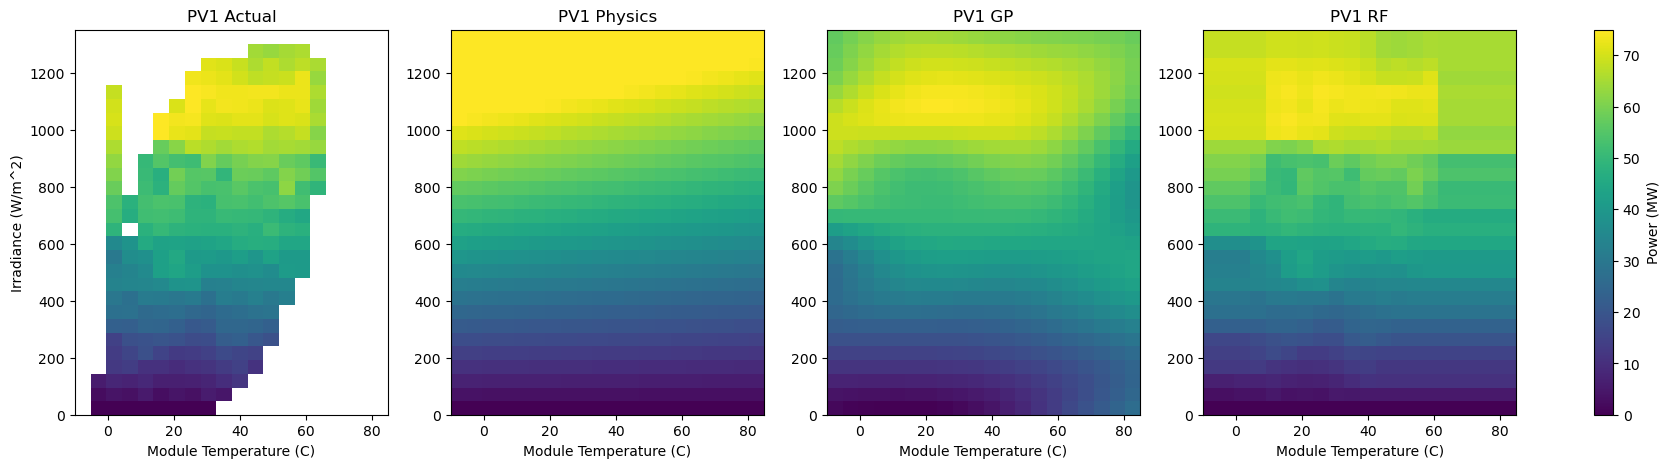

In [22]:
pv1_extent = [grids["PV1"]["x_axis"].min(), grids["PV1"]["x_axis"].max(),
              grids["PV1"]["y_axis"].min(), grids["PV1"]["y_axis"].max()]
pv1_panels = [
    ("Actual", grids["PV1"]["power_grid"]),
    ("Physics", pv1_pred_physics),
    ("GP", pv1_pred_gp),
    ("RF", pv1_pred_rf),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, grid_) in zip(axes, pv1_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=pv1_extent, vmin=0, vmax=CAPACITY_MW["PV1"])
    ax.set_title(f"PV1 {title}")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/pv1_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual, only where actual data exists (blank in the unsampled region, since there is no ground truth there).

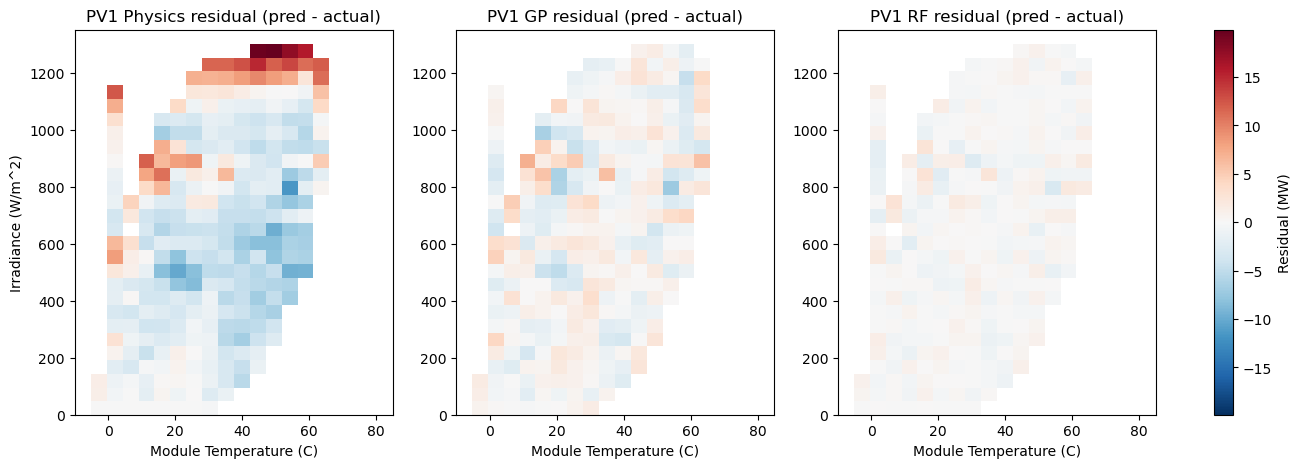

In [23]:
pv1_actual = grids["PV1"]["power_grid"]
pv1_resid_panels = [
    ("Physics", pv1_pred_physics - pv1_actual),
    ("GP", pv1_pred_gp - pv1_actual),
    ("RF", pv1_pred_rf - pv1_actual),
]
max_abs_resid = np.nanmax(np.abs(np.stack([r for _, r in pv1_resid_panels])))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, resid) in zip(axes, pv1_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=pv1_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid, vmax=max_abs_resid)
    ax.set_title(f"PV1 {title} residual (pred - actual)")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/pv1_residuals.png", dpi=150)
plt.show()

### Discussion

All three models learn the same dominant shape: power rises steeply with irradiance and eases
only modestly with module temperature (RF puts 98.8% of its feature importance on irradiance).
The physics formula extrapolates as a smooth linear gradient with no local texture, while GP and
RF both track the actual grid's diagonal footprint more closely inside the sampled region before
smoothing out into the unsampled corners.

The residual heatmaps show the physics formula has the largest, most structured errors, up to
19.9 MW at the (1300 W/m^2, 50 C) cell, matching its higher CV RMSE (5.25 MW vs. 2.54 MW for GP
and 2.25 MW for RF). GP and RF residuals are much smaller (7.3 MW and 3.1 MW max respectively)
and mostly scattered, though both happen to peak at the same (800 W/m^2, 55 C) cell.

The more important difference is in the unsampled region itself: the physics formula is a pure
linear fit with no saturation term, so it keeps climbing past the plant's 75 MW nameplate capacity.
It predicts above 75 MW for 26 of 298 sampled cells (8.7%) and 65 of 262 unsampled cells (24.8%),
peaking at 96.4 MW at the highest-irradiance corner. GP and RF cannot do this: both stay at or
just under the observed maximum by construction (74.8 MW and 74.7 MW respectively), so their
extrapolated predictions stay physically plausible even though they were not designed to enforce
a capacity cap. For extrapolated dispatch estimates in the unsampled region, the physics formula
in its current linear form is the riskier choice; a capacity-aware clip or a saturating formula
would fix this specific failure mode.

### SHAP summary

Global feature importance for the ML models only; the physics formula's two fitted coefficients are already the explanation.

In [24]:
import shap

# SHAP (SHapley Additive exPlanations) breaks each individual prediction down into how many MW
# each input feature added or subtracted relative to the model's average prediction, an idea
# borrowed from cooperative game theory. TreeExplainer computes this exactly and quickly for
# tree-based models like Random Forest, since it can walk the trees' actual decision paths.
pv1_rf_explainer = shap.TreeExplainer(pv1_rf_model)
pv1_rf_shap_values = pv1_rf_explainer.shap_values(X_pv1_ml)
print("PV1 RF SHAP values shape:", pv1_rf_shap_values.shape)

PV1 RF SHAP values shape: (298, 2)


In [25]:
# GP has no tree structure to walk, so it needs the general-purpose Explainer instead, which
# estimates each feature's contribution by repeatedly querying the model. That is slower, so it
# only gets a random sample of 50 background rows (a representative "typical input" baseline for
# comparison) rather than the full dataset, still accurate, just faster to compute.
pv1_gp_background = shap.sample(X_pv1_ml, 50, random_state=0)
pv1_gp_explainer = shap.Explainer(pv1_gp_model.predict, pv1_gp_background)
pv1_gp_shap_values = pv1_gp_explainer(X_pv1_ml)
print("PV1 GP SHAP values shape:", pv1_gp_shap_values.values.shape)

ExactExplainer explainer:  53%|█████▎    | 158/298 [00:00<?, ?it/s]

ExactExplainer explainer:  58%|█████▊    | 173/298 [00:10<00:00, 149.56it/s]

ExactExplainer explainer:  63%|██████▎   | 188/298 [00:10<00:00, 143.24it/s]

ExactExplainer explainer:  69%|██████▉   | 205/298 [00:10<00:00, 153.48it/s]

ExactExplainer explainer:  76%|███████▌  | 227/298 [00:10<00:00, 177.38it/s]

ExactExplainer explainer:  83%|████████▎ | 248/298 [00:10<00:00, 184.99it/s]

ExactExplainer explainer:  90%|████████▉ | 267/298 [00:10<00:00, 183.57it/s]

ExactExplainer explainer:  96%|█████████▋| 287/298 [00:10<00:00, 187.16it/s]

ExactExplainer explainer: 299it [00:10, 13.05it/s]                          

PV1 GP SHAP values shape: (298, 2)


PV1 RF mean |SHAP|: {'irradiance': np.float64(18.237), 'module_temp': np.float64(0.88)}
PV1 GP mean |SHAP|: {'irradiance': np.float64(17.885), 'module_temp': np.float64(0.771)}


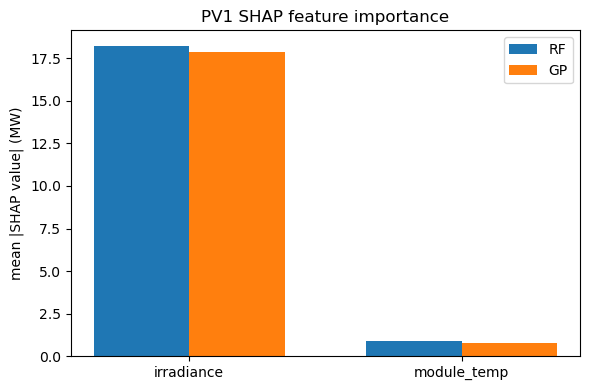

In [26]:
pv1_feature_names = ["irradiance", "module_temp"]
# Average the absolute SHAP contribution per feature across every row, collapsing "how much did
# this feature move this one prediction" into a single number per feature: on average, how much
# does this feature move any prediction, up or down, in MW. A bigger number means a bigger
# typical influence on the model's output.
pv1_rf_mean_abs_shap = np.abs(pv1_rf_shap_values).mean(axis=0)
pv1_gp_mean_abs_shap = np.abs(pv1_gp_shap_values.values).mean(axis=0)
print("PV1 RF mean |SHAP|:", dict(zip(pv1_feature_names, pv1_rf_mean_abs_shap.round(3))))
print("PV1 GP mean |SHAP|:", dict(zip(pv1_feature_names, pv1_gp_mean_abs_shap.round(3))))

x = np.arange(len(pv1_feature_names))
width = 0.35  # bar width, purely cosmetic: keeps the RF/GP bar pairs from overlapping
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, pv1_rf_mean_abs_shap, width, label="RF")
ax.bar(x + width / 2, pv1_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(pv1_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("PV1 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/pv1_shap_summary.png", dpi=150)
plt.show()

### Discussion

SHAP agrees with the RF feature importances above: irradiance dominates both models (RF mean
|SHAP| = 18.2 MW vs. 0.9 MW for module_temp; GP mean |SHAP| = 17.9 MW vs. 0.8 MW). RF and GP
weight module_temp almost identically lightly (0.9 vs. 0.8 MW), consistent with both models'
near-horizontal response-surface panels above and the tiny fitted $\beta_1$ in the physics
formula: module temperature is a real but minor secondary driver of PV1 power, irradiance is
overwhelmingly the dominant one.

### Standalone script export

Exports `models/pv1_model.py`, which refits all three PV1 models on import and exposes `predict(irradiance, module_temp, model=...)`.

In [27]:
from models.pv1_model import predict as pv1_predict

for model_name in ["physics", "gp", "rf"]:
    print(f"models/pv1_model.py predict(800, 40, model='{model_name}') = {pv1_predict(800, 40, model=model_name):.2f} MW")

models/pv1_model.py predict(800, 40, model='physics') = 52.18 MW
models/pv1_model.py predict(800, 40, model='gp') = 54.47 MW
models/pv1_model.py predict(800, 40, model='rf') = 55.17 MW


## PV2 Model

Physics formula and ML models for PV2, mirroring the PV1 model block.

### Tidy long format

Reshape the PV2 grid to one row per (irradiance, module temperature) cell, dropping true NaNs.

In [28]:
irr_mesh_pv2, temp_mesh_pv2 = np.meshgrid(grids["PV2"]["y_axis"], grids["PV2"]["x_axis"], indexing="ij")
pv2_df = pd.DataFrame({
    "irradiance": irr_mesh_pv2.ravel(),
    "module_temp": temp_mesh_pv2.ravel(),
    "power": grids["PV2"]["power_grid"].ravel(),
})
pv2_df = pv2_df.dropna(subset=["power"]).reset_index(drop=True)

In [29]:
n_rows_pv2, n_cols_pv2 = grids["PV2"]["power_grid"].shape
print(f"PV2: retained {len(pv2_df)} of {n_rows_pv2 * n_cols_pv2} grid cells ({n_rows_pv2} irradiance x {n_cols_pv2} temperature)")

PV2: retained 268 of 560 grid cells (28 irradiance x 20 temperature)


### Physics formula

Same linear temperature-coefficient model [1] used for PV1, refit here on PV2's own tidy data
rather than reusing PV1's coefficients, since the two plants are physically separate arrays and
are expected to have different fitted parameters:

$$P = \beta_0 \cdot G + \beta_1 \cdot G \cdot (T_m - 25)$$

Fit by ordinary least squares on $[G,\ G(T_m-25)]$ with no intercept, same as PV1.

In [30]:
X_pv2 = np.column_stack([pv2_df["irradiance"], pv2_df["irradiance"] * (pv2_df["module_temp"] - 25)])
y_pv2 = pv2_df["power"].to_numpy()

# fit_intercept=False: same reasoning as PV1, zero irradiance should mean zero power.
pv2_physics_model = LinearRegression(fit_intercept=False).fit(X_pv2, y_pv2)
beta0_pv2, beta1_pv2 = pv2_physics_model.coef_
print(f"PV2 physics formula: beta0 = {beta0_pv2:.5f} MW per W/m^2, beta1 = {beta1_pv2:.6f} MW per W/m^2 per degC")

PV2 physics formula: beta0 = 0.06077 MW per W/m^2, beta1 = -0.000160 MW per W/m^2 per degC


### Physics formula cross-validation

5-fold CV $R^2$/RMSE for the PV2 physics formula, using the same `cv_evaluate` helper defined in
the PV1 block, so the metrics are directly comparable across the two plants.

In [31]:
r2_pv2_physics, rmse_pv2_physics = cv_evaluate(lambda: LinearRegression(fit_intercept=False), X_pv2, y_pv2)
print(f"PV2 physics formula 5-fold CV: R^2 = {r2_pv2_physics.mean():.4f} +/- {r2_pv2_physics.std():.4f}, "
      f"RMSE = {rmse_pv2_physics.mean():.4f} +/- {rmse_pv2_physics.std():.4f} MW")

PV2 physics formula 5-fold CV: R^2 = 0.9722 +/- 0.0047, RMSE = 3.4112 +/- 0.3539 MW


### Gaussian Process Regression

Primary ML comparison model for PV2, same `make_gp()` factory (scaled RBF + white-noise kernel)
defined in the PV1 block, refit here on PV2's tidy data.

In [32]:
# Same raw-feature fix as PV1: GP/RF map (irradiance, module_temp) directly, not the
# physics-transformed [G, G*(Tm-25)] features used for the OLS fit above.
X_pv2_ml = np.column_stack([pv2_df["irradiance"], pv2_df["module_temp"]])

pv2_gp_model = make_gp().fit(X_pv2_ml, y_pv2)
print("PV2 GP fitted kernel:", pv2_gp_model.named_steps["gaussianprocessregressor"].kernel_)

PV2 GP fitted kernel: 0.833**2 * RBF(length_scale=[0.726, 1.45]) + WhiteKernel(noise_level=0.00301)


### GP cross-validation

5-fold CV $R^2$/RMSE for the PV2 GP model, using the same `cv_evaluate` helper and fold count as
every other model in the notebook.

In [33]:
r2_pv2_gp, rmse_pv2_gp = cv_evaluate(make_gp, X_pv2_ml, y_pv2)
print(f"PV2 GP 5-fold CV: R^2 = {r2_pv2_gp.mean():.4f} +/- {r2_pv2_gp.std():.4f}, "
      f"RMSE = {rmse_pv2_gp.mean():.4f} +/- {rmse_pv2_gp.std():.4f} MW")

PV2 GP 5-fold CV: R^2 = 0.9961 +/- 0.0012, RMSE = 1.2715 +/- 0.1686 MW


### Random Forest

Secondary ML contrast for PV2, same `make_rf()` factory defined in the PV1 block, refit here on
PV2's tidy data to see whether the irradiance-dominant feature importance pattern from PV1 holds.

In [34]:
pv2_rf_model = make_rf().fit(X_pv2_ml, y_pv2)
importances_pv2 = pv2_rf_model.feature_importances_
print(f"PV2 RF feature importances: irradiance = {importances_pv2[0]:.3f}, module_temp = {importances_pv2[1]:.3f}")

PV2 RF feature importances: irradiance = 0.988, module_temp = 0.012


### Random Forest cross-validation

5-fold CV $R^2$/RMSE for the PV2 Random Forest model, directly comparable to the physics formula
and GP numbers above.

In [35]:
r2_pv2_rf, rmse_pv2_rf = cv_evaluate(make_rf, X_pv2_ml, y_pv2)
print(f"PV2 RF 5-fold CV: R^2 = {r2_pv2_rf.mean():.4f} +/- {r2_pv2_rf.std():.4f}, "
      f"RMSE = {rmse_pv2_rf.mean():.4f} +/- {rmse_pv2_rf.std():.4f} MW")

PV2 RF 5-fold CV: R^2 = 0.9935 +/- 0.0017, RMSE = 1.6397 +/- 0.1774 MW


### Full-grid predictions

Predict all three PV2 models (physics, GP, RF) over the complete native grid, including the
unsampled cells, the same way as PV1, so the two plants' extrapolation behavior can be compared
side by side.

In [36]:
full_irr_mesh_pv2, full_temp_mesh_pv2 = np.meshgrid(grids["PV2"]["y_axis"], grids["PV2"]["x_axis"], indexing="ij")
X_pv2_full = np.column_stack([full_irr_mesh_pv2.ravel(), full_temp_mesh_pv2.ravel()])
X_pv2_full_physics = np.column_stack([X_pv2_full[:, 0], X_pv2_full[:, 0] * (X_pv2_full[:, 1] - 25)])

pv2_pred_physics = pv2_physics_model.predict(X_pv2_full_physics).reshape(full_irr_mesh_pv2.shape)
pv2_pred_gp = pv2_gp_model.predict(X_pv2_full).reshape(full_irr_mesh_pv2.shape)
pv2_pred_rf = pv2_rf_model.predict(X_pv2_full).reshape(full_irr_mesh_pv2.shape)
print("PV2 full-grid predictions shape:", pv2_pred_physics.shape)

PV2 full-grid predictions shape: (28, 20)


### Response-surface heatmaps

Actual PV2 grid next to each model's full-grid prediction, same color scale and layout as the
PV1 figure, the central PV2 figure.

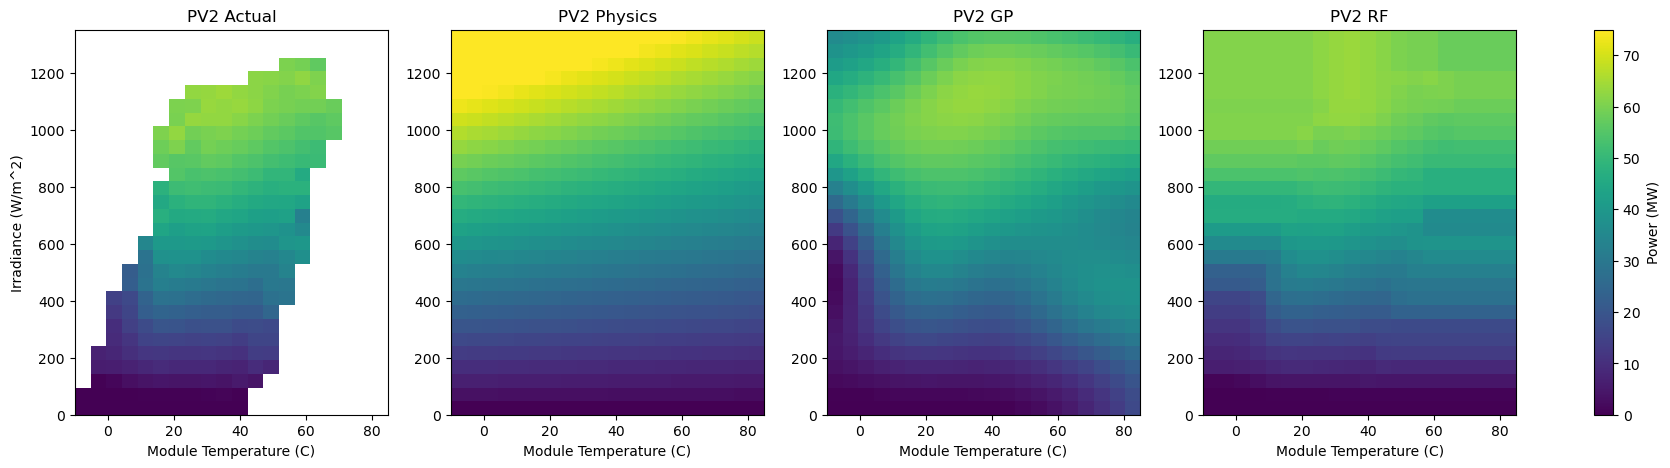

In [37]:
pv2_extent = [grids["PV2"]["x_axis"].min(), grids["PV2"]["x_axis"].max(),
              grids["PV2"]["y_axis"].min(), grids["PV2"]["y_axis"].max()]
pv2_panels = [
    ("Actual", grids["PV2"]["power_grid"]),
    ("Physics", pv2_pred_physics),
    ("GP", pv2_pred_gp),
    ("RF", pv2_pred_rf),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, grid_) in zip(axes, pv2_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=pv2_extent, vmin=0, vmax=CAPACITY_MW["PV2"])
    ax.set_title(f"PV2 {title}")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/pv2_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual for PV2, only where actual data exists (blank in the unsampled region,
since there is no ground truth there), same layout as the PV1 residual figure.

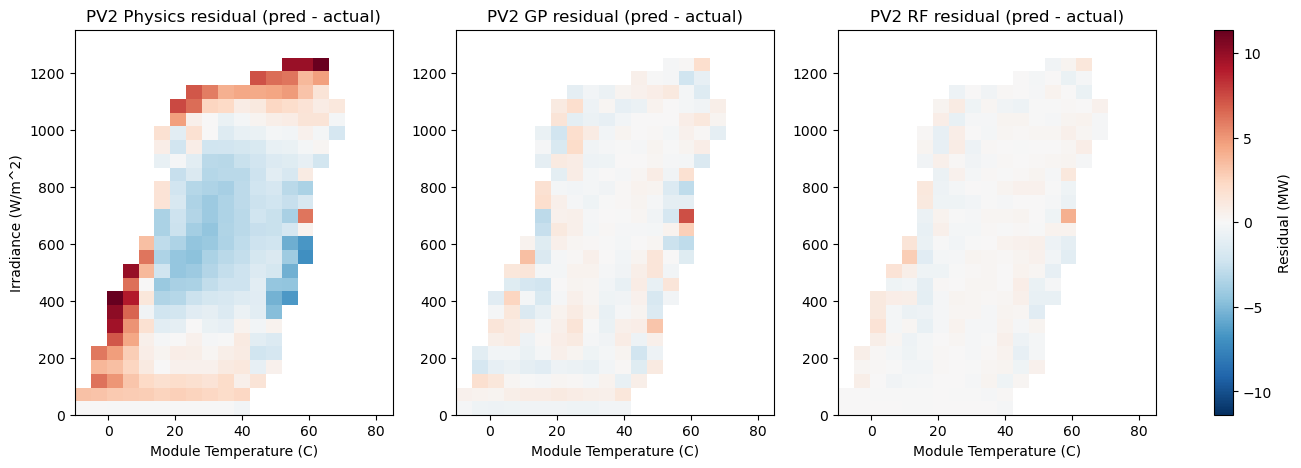

In [38]:
pv2_actual = grids["PV2"]["power_grid"]
pv2_resid_panels = [
    ("Physics", pv2_pred_physics - pv2_actual),
    ("GP", pv2_pred_gp - pv2_actual),
    ("RF", pv2_pred_rf - pv2_actual),
]
max_abs_resid_pv2 = np.nanmax(np.abs(np.stack([r for _, r in pv2_resid_panels])))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, resid) in zip(axes, pv2_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=pv2_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid_pv2, vmax=max_abs_resid_pv2)
    ax.set_title(f"PV2 {title} residual (pred - actual)")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/pv2_residuals.png", dpi=150)
plt.show()

### Discussion

PV2 shows the same overall pattern as PV1, but with tighter fits across all three models:
physics $R^2$ = 0.9722 (RMSE = 3.41 MW), GP $R^2$ = 0.9961 (RMSE = 1.27 MW), RF $R^2$ = 0.9935
(RMSE = 1.64 MW), all beating their PV1 counterparts (5.25 / 2.54 / 2.25 MW respectively). The
residual heatmaps put the physics formula's error where PV1's did: structured, up to 11.4 MW at
the (400 W/m^2, 0 C) cell, while GP and RF residuals are smaller (7.4 MW and 4.1 MW max) and
mostly scattered, aside from a shared outlier cell at (700 W/m^2, 60 C) that both ML models miss
in the same spot.

The extrapolation risk shows up again but milder: the linear physics formula, with no saturation
term, predicts above PV2's 75 MW nameplate capacity in 40 of 292 unsampled cells (13.7%, versus
PV1's 24.8%) while staying within cap on every sampled cell, peaking at 89.6 MW in the
highest-irradiance corner. GP and RF again stay bounded by construction, topping out near
63 MW across the full grid. The conclusion from PV1 carries over: for extrapolated dispatch
estimates in the unsampled region, the physics formula's raw linear form is the riskier choice
for PV2 as well.

### SHAP summary

Global feature importance for the PV2 GP and RF models, same approach as PV1 (TreeExplainer for
RF, a sampled-background KernelExplainer-style `Explainer` for GP); the physics formula needs no
SHAP since its two fitted coefficients are already the explanation.

In [39]:
pv2_rf_explainer = shap.TreeExplainer(pv2_rf_model)
pv2_rf_shap_values = pv2_rf_explainer.shap_values(X_pv2_ml)
print("PV2 RF SHAP values shape:", pv2_rf_shap_values.shape)

PV2 RF SHAP values shape: (268, 2)


In [40]:
pv2_gp_background = shap.sample(X_pv2_ml, 50, random_state=0)
pv2_gp_explainer = shap.Explainer(pv2_gp_model.predict, pv2_gp_background)
pv2_gp_shap_values = pv2_gp_explainer(X_pv2_ml)
print("PV2 GP SHAP values shape:", pv2_gp_shap_values.values.shape)

PV2 GP SHAP values shape: (268, 2)


PV2 RF mean |SHAP|: {'irradiance': np.float64(18.135), 'module_temp': np.float64(1.251)}
PV2 GP mean |SHAP|: {'irradiance': np.float64(17.345), 'module_temp': np.float64(1.458)}


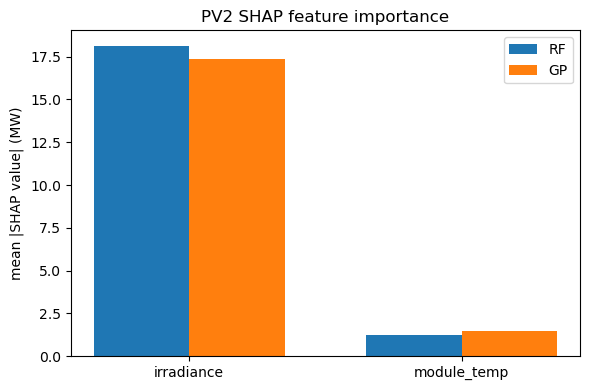

In [41]:
pv2_feature_names = ["irradiance", "module_temp"]
pv2_rf_mean_abs_shap = np.abs(pv2_rf_shap_values).mean(axis=0)
pv2_gp_mean_abs_shap = np.abs(pv2_gp_shap_values.values).mean(axis=0)
print("PV2 RF mean |SHAP|:", dict(zip(pv2_feature_names, pv2_rf_mean_abs_shap.round(3))))
print("PV2 GP mean |SHAP|:", dict(zip(pv2_feature_names, pv2_gp_mean_abs_shap.round(3))))

x = np.arange(len(pv2_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, pv2_rf_mean_abs_shap, width, label="RF")
ax.bar(x + width / 2, pv2_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(pv2_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("PV2 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/pv2_shap_summary.png", dpi=150)
plt.show()

### Discussion

Same story as PV1: irradiance dominates both PV2 models (RF mean |SHAP| = 18.1 MW vs. 1.3 MW for
module_temp; GP mean |SHAP| = 17.3 MW vs. 1.5 MW). Module_temp carries a bit more weight here than
in PV1 for both models (1.3-1.5 MW vs. PV1's 0.8-0.9 MW), matching PV2's larger-magnitude fitted
$\beta_1$ (-0.000160 vs. PV1's -0.000124), but irradiance still overwhelmingly dominates in both
plants.

### Standalone script export

Exports `models/pv2_model.py`, which refits all three PV2 models on import and exposes
`predict(irradiance, module_temp, model=...)`, mirroring `models/pv1_model.py`.

In [42]:
from models.pv2_model import predict as pv2_predict

for model_name in ["physics", "gp", "rf"]:
    print(f"models/pv2_model.py predict(800, 40, model='{model_name}') = {pv2_predict(800, 40, model=model_name):.2f} MW")

models/pv2_model.py predict(800, 40, model='physics') = 46.70 MW
models/pv2_model.py predict(800, 40, model='gp') = 49.79 MW
models/pv2_model.py predict(800, 40, model='rf') = 49.99 MW


## PV-combined Model

Physics formula and ML models fit on PV1 and PV2 pooled together, with plant as an added
categorical feature, to check whether pooling helps or hurts versus the two standalone models.

### Tidy long format

Pool PV1's and PV2's already-tidy DataFrames, each tagged with a `plant` column, into one combined
table; both were already dropped of true NaNs when they were built, so no further filtering is
needed here.

In [43]:
pv_combined_df = pd.concat(
    [pv1_df.assign(plant="PV1"), pv2_df.assign(plant="PV2")],
    ignore_index=True,
)
print(f"PV-combined: {len(pv_combined_df)} rows ({(pv_combined_df['plant'] == 'PV1').sum()} PV1 + "
      f"{(pv_combined_df['plant'] == 'PV2').sum()} PV2)")

PV-combined: 566 rows (298 PV1 + 268 PV2)


### Physics formula

Same linear temperature-coefficient model [1] as PV1/PV2, fit once on the pooled data with no
plant term, the cleanest test of whether a single shared formula generalizes across both plants:

$$P = \beta_0 \cdot G + \beta_1 \cdot G \cdot (T_m - 25)$$

Fit by ordinary least squares on $[G,\ G(T_m-25)]$ with no intercept, same as the standalone
models. GP and RF (below) get plant as a one-hot feature instead, since tree- and kernel-based
models can use a categorical dimension directly without this restriction.

In [44]:
X_pv_comb = np.column_stack([pv_combined_df["irradiance"], pv_combined_df["irradiance"] * (pv_combined_df["module_temp"] - 25)])
y_pv_comb = pv_combined_df["power"].to_numpy()

# fit_intercept=False: same reasoning as PV1, zero irradiance should mean zero power.
pv_comb_physics_model = LinearRegression(fit_intercept=False).fit(X_pv_comb, y_pv_comb)
beta0_pv_comb, beta1_pv_comb = pv_comb_physics_model.coef_
print(f"PV-combined physics formula: beta0 = {beta0_pv_comb:.5f} MW per W/m^2, beta1 = {beta1_pv_comb:.6f} MW per W/m^2 per degC")

PV-combined physics formula: beta0 = 0.06458 MW per W/m^2, beta1 = -0.000160 MW per W/m^2 per degC


### Physics formula cross-validation

5-fold CV $R^2$/RMSE for the pooled physics formula, using the same `cv_evaluate` helper as every
other model, so this is directly comparable to the standalone PV1 and PV2 physics numbers.

In [45]:
r2_pv_comb_physics, rmse_pv_comb_physics = cv_evaluate(lambda: LinearRegression(fit_intercept=False), X_pv_comb, y_pv_comb)
print(f"PV-combined physics formula 5-fold CV: R^2 = {r2_pv_comb_physics.mean():.4f} +/- {r2_pv_comb_physics.std():.4f}, "
      f"RMSE = {rmse_pv_comb_physics.mean():.4f} +/- {rmse_pv_comb_physics.std():.4f} MW")

PV-combined physics formula 5-fold CV: R^2 = 0.9441 +/- 0.0076, RMSE = 5.1009 +/- 0.3459 MW


### Gaussian Process Regression

GP on the pooled data with plant one-hot encoded as a third feature (`is_PV2`), so a plant
boundary can shift the surface if the two plants behave differently. Needs its own kernel factory
since `make_gp()` is hardcoded to a 2-feature length scale.

In [46]:
is_pv2_comb = (pv_combined_df["plant"] == "PV2").astype(float)
X_pv_comb_ml = np.column_stack([pv_combined_df["irradiance"], pv_combined_df["module_temp"], is_pv2_comb])

def make_gp_combined():
    # Same kernel structure as PV1's make_gp() (see that block for what ConstantKernel/RBF/
    # WhiteKernel and each hyperparameter mean), just with a third RBF length scale added for
    # the new is_PV2 feature, so the fitted surface can shift by plant if needed.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF([1.0, 1.0, 1.0], (1e-2, 1e2)) + WhiteKernel(1.0, (1e-5, 1e2))
    return make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0),
    )

pv_comb_gp_model = make_gp_combined().fit(X_pv_comb_ml, y_pv_comb)
print("PV-combined GP fitted kernel:", pv_comb_gp_model.named_steps["gaussianprocessregressor"].kernel_)

PV-combined GP fitted kernel: 0.725**2 * RBF(length_scale=[0.484, 0.973, 4.6]) + WhiteKernel(noise_level=0.00583)


### GP cross-validation

5-fold CV $R^2$/RMSE for the PV-combined GP model, same helper and fold count as every other
model.

In [47]:
r2_pv_comb_gp, rmse_pv_comb_gp = cv_evaluate(make_gp_combined, X_pv_comb_ml, y_pv_comb)
print(f"PV-combined GP 5-fold CV: R^2 = {r2_pv_comb_gp.mean():.4f} +/- {r2_pv_comb_gp.std():.4f}, "
      f"RMSE = {rmse_pv_comb_gp.mean():.4f} +/- {rmse_pv_comb_gp.std():.4f} MW")

PV-combined GP 5-fold CV: R^2 = 0.9920 +/- 0.0016, RMSE = 1.9206 +/- 0.1613 MW


### Random Forest

RF on the same pooled features (`irradiance`, `module_temp`, `is_PV2`), same `make_rf()` factory
as the standalone models; RF's split-based structure needs no special handling for the extra
categorical dimension.

In [48]:
pv_comb_rf_model = make_rf().fit(X_pv_comb_ml, y_pv_comb)
importances_pv_comb = pv_comb_rf_model.feature_importances_
print(f"PV-combined RF feature importances: irradiance = {importances_pv_comb[0]:.3f}, "
      f"module_temp = {importances_pv_comb[1]:.3f}, is_PV2 = {importances_pv_comb[2]:.3f}")

PV-combined RF feature importances: irradiance = 0.967, module_temp = 0.012, is_PV2 = 0.021


### Random Forest cross-validation

5-fold CV $R^2$/RMSE for the PV-combined Random Forest model, directly comparable to the physics
formula and GP numbers above.

In [49]:
r2_pv_comb_rf, rmse_pv_comb_rf = cv_evaluate(make_rf, X_pv_comb_ml, y_pv_comb)
print(f"PV-combined RF 5-fold CV: R^2 = {r2_pv_comb_rf.mean():.4f} +/- {r2_pv_comb_rf.std():.4f}, "
      f"RMSE = {rmse_pv_comb_rf.mean():.4f} +/- {rmse_pv_comb_rf.std():.4f} MW")

PV-combined RF 5-fold CV: R^2 = 0.9911 +/- 0.0017, RMSE = 2.0304 +/- 0.1418 MW


### Full-grid predictions

Predict over the complete native grid (PV1 and PV2 share the same irradiance/temperature axes)
twice for GP and RF, once with `is_PV2=0` and once with `is_PV2=1`, so each plant's prediction
can be compared to its own actual grid. The physics formula has no plant term, so it produces one
shared prediction grid used for both comparisons.

In [50]:
full_irr_mesh_comb, full_temp_mesh_comb = np.meshgrid(grids["PV1"]["y_axis"], grids["PV1"]["x_axis"], indexing="ij")
X_full_comb = np.column_stack([full_irr_mesh_comb.ravel(), full_temp_mesh_comb.ravel()])
X_full_comb_physics = np.column_stack([X_full_comb[:, 0], X_full_comb[:, 0] * (X_full_comb[:, 1] - 25)])
zeros_full, ones_full = np.zeros(len(X_full_comb)), np.ones(len(X_full_comb))

pv_comb_pred_physics = pv_comb_physics_model.predict(X_full_comb_physics).reshape(full_irr_mesh_comb.shape)
pv_comb_pred_gp_pv1 = pv_comb_gp_model.predict(np.column_stack([X_full_comb, zeros_full])).reshape(full_irr_mesh_comb.shape)
pv_comb_pred_gp_pv2 = pv_comb_gp_model.predict(np.column_stack([X_full_comb, ones_full])).reshape(full_irr_mesh_comb.shape)
pv_comb_pred_rf_pv1 = pv_comb_rf_model.predict(np.column_stack([X_full_comb, zeros_full])).reshape(full_irr_mesh_comb.shape)
pv_comb_pred_rf_pv2 = pv_comb_rf_model.predict(np.column_stack([X_full_comb, ones_full])).reshape(full_irr_mesh_comb.shape)
print("PV-combined full-grid predictions shape:", pv_comb_pred_physics.shape)

PV-combined full-grid predictions shape: (28, 20)


### Response-surface heatmaps

Two rows, one per plant: each plant's actual grid next to the shared physics prediction and that
plant's own GP/RF prediction (`is_PV2` set accordingly), the central PV-combined figure.

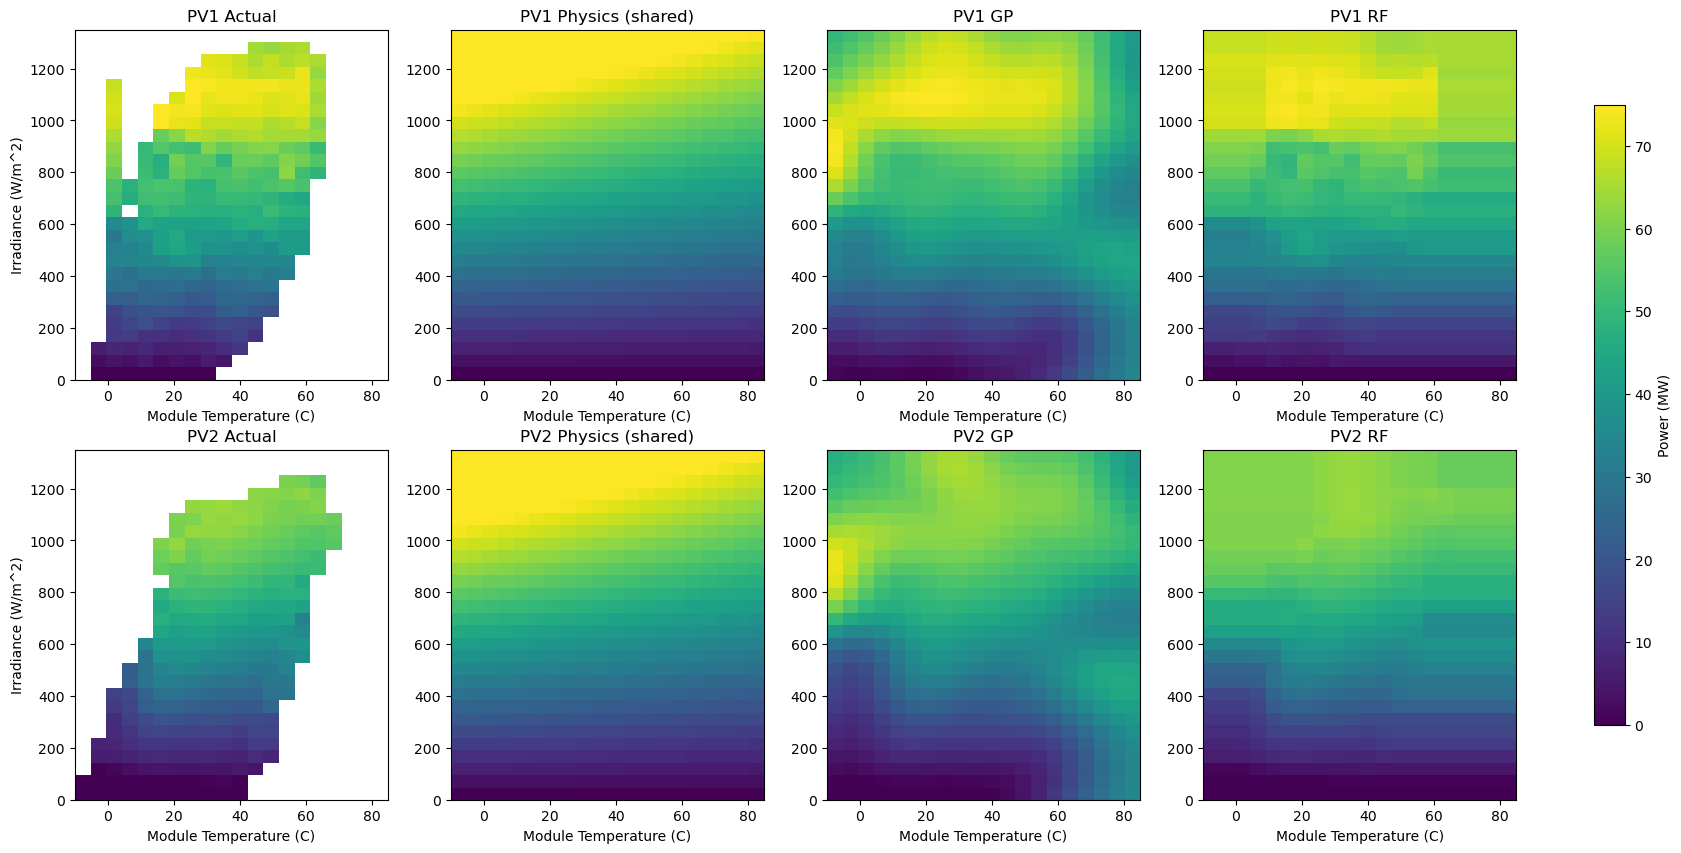

In [51]:
pv_comb_extent = [grids["PV1"]["x_axis"].min(), grids["PV1"]["x_axis"].max(),
                   grids["PV1"]["y_axis"].min(), grids["PV1"]["y_axis"].max()]
pv_comb_rows = [
    ("PV1", grids["PV1"]["power_grid"], pv_comb_pred_gp_pv1, pv_comb_pred_rf_pv1),
    ("PV2", grids["PV2"]["power_grid"], pv_comb_pred_gp_pv2, pv_comb_pred_rf_pv2),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for row, (plant, actual, pred_gp, pred_rf) in enumerate(pv_comb_rows):
    panels = [("Actual", actual), ("Physics (shared)", pv_comb_pred_physics), ("GP", pred_gp), ("RF", pred_rf)]
    for ax, (title, grid_) in zip(axes[row], panels):
        im = ax.imshow(grid_, origin="lower", aspect="auto", extent=pv_comb_extent, vmin=0, vmax=75.0)
        ax.set_title(f"{plant} {title}")
        ax.set_xlabel("Module Temperature (C)")
    axes[row][0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/pv_combined_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual per plant, only where actual data exists, same two-row layout as the
response-surface figure above.

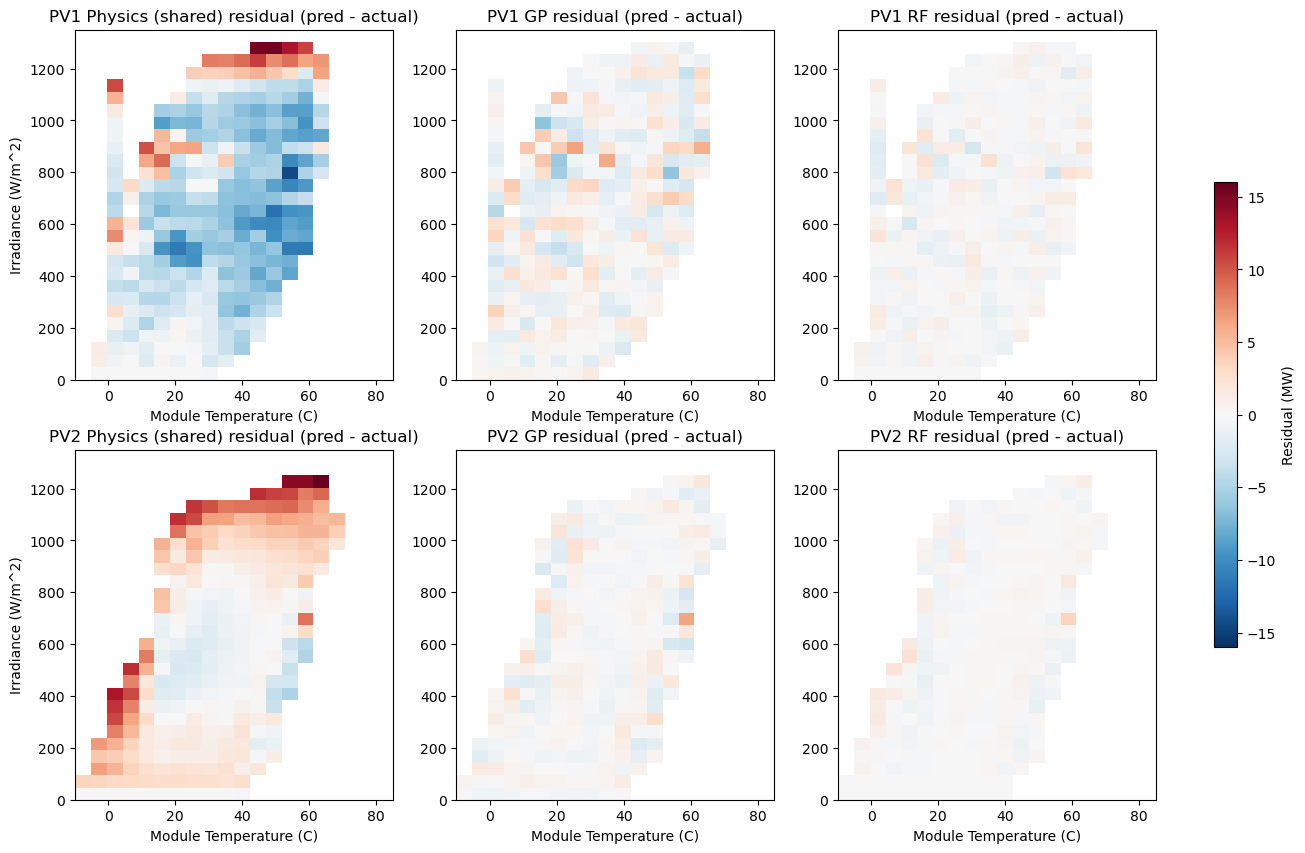

In [52]:
pv_comb_resid_rows = [
    ("PV1", grids["PV1"]["power_grid"], pv_comb_pred_gp_pv1, pv_comb_pred_rf_pv1),
    ("PV2", grids["PV2"]["power_grid"], pv_comb_pred_gp_pv2, pv_comb_pred_rf_pv2),
]
pv_comb_all_resid = []
for _, actual, pred_gp, pred_rf in pv_comb_resid_rows:
    pv_comb_all_resid += [pv_comb_pred_physics - actual, pred_gp - actual, pred_rf - actual]
max_abs_resid_comb = np.nanmax(np.abs(np.stack(pv_comb_all_resid)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (plant, actual, pred_gp, pred_rf) in enumerate(pv_comb_resid_rows):
    resid_panels = [
        ("Physics (shared)", pv_comb_pred_physics - actual),
        ("GP", pred_gp - actual),
        ("RF", pred_rf - actual),
    ]
    for ax, (title, resid) in zip(axes[row], resid_panels):
        im = ax.imshow(resid, origin="lower", aspect="auto", extent=pv_comb_extent,
                        cmap="RdBu_r", vmin=-max_abs_resid_comb, vmax=max_abs_resid_comb)
        ax.set_title(f"{plant} {title} residual (pred - actual)")
        ax.set_xlabel("Module Temperature (C)")
    axes[row][0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/pv_combined_residuals.png", dpi=150)
plt.show()

### Discussion

The shared physics formula splits the difference between the two plants' own fitted slopes
(pooled $\beta_0$ = 0.0646 vs. PV1's 0.0671 and PV2's 0.0608) and its residuals show it: PV1 is
mostly underpredicted (up to -15.4 MW, blue) while PV2 is mostly overpredicted (up to +16.0 MW,
red), a systematic plant-level bias that a single shared line cannot avoid. GP and RF, which get
`is_PV2` as an extra feature, track each plant's own grid much more closely (GP: 6.5 MW PV1 /
6.3 MW PV2 max residual; RF: 3.0 MW PV1 / 3.6 MW PV2), comparable to or tighter than their
standalone per-plant residuals (PV1 standalone: GP 7.3 MW, RF 3.1 MW; PV2 standalone: GP 7.4 MW,
RF 4.1 MW).

The extrapolation risk is again the physics formula's weak point, and pooling makes it worse for
PV2 specifically: the shared line predicts above 75 MW capacity in 54 of 262 PV1 unsampled cells
(20.6%, close to PV1 standalone's 24.8%) but in 68 of 292 PV2 unsampled cells (23.3%, well above
PV2 standalone's 13.7%), because the pooled $\beta_0$ is pulled up from PV2's own lower value. GP
and RF stay bounded for both plants regardless (max predictions 75.0/74.7 MW for PV1, 72.8/63.6 MW
for PV2), so the capacity-cap risk finding from the standalone models carries over unchanged to
the combined model.

### SHAP summary

Global feature importance for the PV-combined GP and RF models over all three features
(`irradiance`, `module_temp`, `is_PV2`), same TreeExplainer/sampled-background approach as the
standalone models; this shows how much weight the plant identity itself carries relative to the
physical inputs.

In [53]:
pv_comb_rf_explainer = shap.TreeExplainer(pv_comb_rf_model)
pv_comb_rf_shap_values = pv_comb_rf_explainer.shap_values(X_pv_comb_ml)
print("PV-combined RF SHAP values shape:", pv_comb_rf_shap_values.shape)

PV-combined RF SHAP values shape: (566, 3)


In [54]:
pv_comb_gp_background = shap.sample(X_pv_comb_ml, 50, random_state=0)
pv_comb_gp_explainer = shap.Explainer(pv_comb_gp_model.predict, pv_comb_gp_background)
pv_comb_gp_shap_values = pv_comb_gp_explainer(X_pv_comb_ml)
print("PV-combined GP SHAP values shape:", pv_comb_gp_shap_values.values.shape)

PV-combined GP SHAP values shape: (566, 3)


PV-combined RF mean |SHAP|: {'irradiance': np.float64(18.378), 'module_temp': np.float64(0.946), 'is_PV2': np.float64(2.966)}
PV-combined GP mean |SHAP|: {'irradiance': np.float64(17.837), 'module_temp': np.float64(0.942), 'is_PV2': np.float64(3.045)}


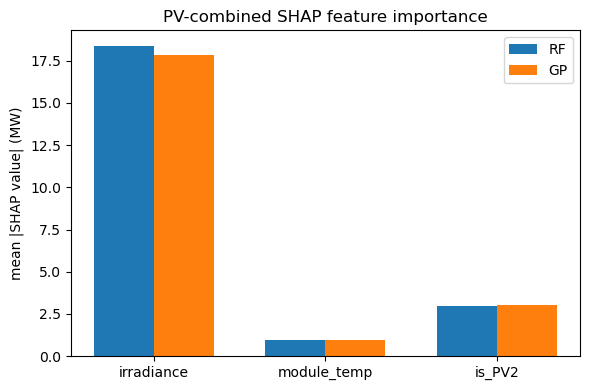

In [55]:
pv_comb_feature_names = ["irradiance", "module_temp", "is_PV2"]
pv_comb_rf_mean_abs_shap = np.abs(pv_comb_rf_shap_values).mean(axis=0)
pv_comb_gp_mean_abs_shap = np.abs(pv_comb_gp_shap_values.values).mean(axis=0)
print("PV-combined RF mean |SHAP|:", dict(zip(pv_comb_feature_names, pv_comb_rf_mean_abs_shap.round(3))))
print("PV-combined GP mean |SHAP|:", dict(zip(pv_comb_feature_names, pv_comb_gp_mean_abs_shap.round(3))))

x = np.arange(len(pv_comb_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, pv_comb_rf_mean_abs_shap, width, label="RF")
ax.bar(x + width / 2, pv_comb_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(pv_comb_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("PV-combined SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/pv_combined_shap_summary.png", dpi=150)
plt.show()

### Discussion

Irradiance still dominates overwhelmingly (RF mean |SHAP| = 18.4 MW, GP = 17.8 MW), but plant
identity now outweighs module temperature: `is_PV2` carries more SHAP weight than `module_temp`
for both models (RF: 3.0 vs. 0.9 MW; GP: 3.0 vs. 0.9 MW). That matches the response-surface and
residual findings above: the same irradiance and module temperature produce a meaningfully
different power output depending on which plant it came from, enough that the models treat plant
identity as a stronger signal than the module-temperature correction term the physics formula
relies on.

### Leave-one-plant-out transferability check

Train each model on one plant's cells only and test on the other plant's, in both directions.
This is the real generalization stress test for the combined model: does a relationship learned
from one plant's data transfer to the other, or does pooling only work because both plants were
seen during training? For GP/RF this trains on raw `[irradiance, module_temp]` with no `is_PV2`
feature, since the training plant is constant within each direction and the feature would carry
no information anyway.

In [56]:
for train_name, test_name in [("PV1", "PV2"), ("PV2", "PV1")]:
    train_df = pv1_df if train_name == "PV1" else pv2_df
    test_df = pv1_df if test_name == "PV1" else pv2_df
    X_train = np.column_stack([train_df["irradiance"], train_df["irradiance"] * (train_df["module_temp"] - 25)])
    X_test = np.column_stack([test_df["irradiance"], test_df["irradiance"] * (test_df["module_temp"] - 25)])
    y_train, y_test = train_df["power"].to_numpy(), test_df["power"].to_numpy()

    model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"Physics trained on {train_name}, tested on {test_name}: R^2 = {r2:.4f}, RMSE = {rmse:.4f} MW")

Physics trained on PV1, tested on PV2: R^2 = 0.9207, RMSE = 5.8346 MW
Physics trained on PV2, tested on PV1: R^2 = 0.8875, RMSE = 7.2429 MW


In [57]:
for train_name, test_name in [("PV1", "PV2"), ("PV2", "PV1")]:
    train_df = pv1_df if train_name == "PV1" else pv2_df
    test_df = pv1_df if test_name == "PV1" else pv2_df
    X_train = np.column_stack([train_df["irradiance"], train_df["module_temp"]])
    X_test = np.column_stack([test_df["irradiance"], test_df["module_temp"]])
    y_train, y_test = train_df["power"].to_numpy(), test_df["power"].to_numpy()

    model = make_gp().fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"GP trained on {train_name}, tested on {test_name}: R^2 = {r2:.4f}, RMSE = {rmse:.4f} MW")

GP trained on PV1, tested on PV2: R^2 = 0.8881, RMSE = 6.9334 MW


GP trained on PV2, tested on PV1: R^2 = 0.8605, RMSE = 8.0653 MW


In [58]:
for train_name, test_name in [("PV1", "PV2"), ("PV2", "PV1")]:
    train_df = pv1_df if train_name == "PV1" else pv2_df
    test_df = pv1_df if test_name == "PV1" else pv2_df
    X_train = np.column_stack([train_df["irradiance"], train_df["module_temp"]])
    X_test = np.column_stack([test_df["irradiance"], test_df["module_temp"]])
    y_train, y_test = train_df["power"].to_numpy(), test_df["power"].to_numpy()

    model = make_rf().fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"RF trained on {train_name}, tested on {test_name}: R^2 = {r2:.4f}, RMSE = {rmse:.4f} MW")

RF trained on PV1, tested on PV2: R^2 = 0.8828, RMSE = 7.0939 MW


RF trained on PV2, tested on PV1: R^2 = 0.8897, RMSE = 7.1691 MW


### Discussion

All three models degrade sharply when tested on a completely unseen plant: RMSE rises to
5.8-8.1 MW, well above both the standalone within-plant CV numbers (physics 3.4-5.3 MW, GP
1.3-2.5 MW, RF 1.6-2.3 MW) and the pooled-with-both-plants-seen CV numbers (physics 5.1 MW, GP
1.9 MW, RF 2.0 MW). Pooling clearly helps when both plants are represented in training, GP and
RF's pooled CV RMSE is close to their better standalone plant's number, but that benefit depends
on having at least some data from the plant being predicted.

The ranking flips under this stress test: physics ($R^2$ = 0.89-0.92) generalizes to the unseen
plant better than GP ($R^2$ = 0.86-0.89) or RF ($R^2$ = 0.88-0.89), the opposite of every within-plant
comparison in this notebook. A 2-parameter linear formula has less freedom to overfit
plant-specific quirks, so it transfers its shared shape more reliably than the flexible ML
models, which pick up more of the training plant's local texture at the cost of portability. For
this project, pooling is worth doing when both plants have data, GP/RF benefit and lose nothing,
but the physics formula is the safer default for a genuinely new, unseen PV plant with no data of
its own yet.

### Standalone script export

Exports `models/pv_combined_model.py`, which refits all three PV-combined models on import and
exposes `predict(irradiance, module_temp, plant, model=...)`; the physics prediction ignores
`plant` since it has no plant term, but the parameter is still accepted for a consistent
interface across all three models.

In [59]:
from models.pv_combined_model import predict as pv_combined_predict

for plant in ["PV1", "PV2"]:
    for model_name in ["physics", "gp", "rf"]:
        pred = pv_combined_predict(800, 40, plant=plant, model=model_name)
        print(f"models/pv_combined_model.py predict(800, 40, plant='{plant}', model='{model_name}') = {pred:.2f} MW")

models/pv_combined_model.py predict(800, 40, plant='PV1', model='physics') = 49.74 MW
models/pv_combined_model.py predict(800, 40, plant='PV1', model='gp') = 53.81 MW
models/pv_combined_model.py predict(800, 40, plant='PV1', model='rf') = 55.21 MW
models/pv_combined_model.py predict(800, 40, plant='PV2', model='physics') = 49.74 MW
models/pv_combined_model.py predict(800, 40, plant='PV2', model='gp') = 49.66 MW
models/pv_combined_model.py predict(800, 40, plant='PV2', model='rf') = 49.94 MW


## Wind1 Model

Data-driven models only for Wind1: the grid is fully dense (100% fill), so there is no
unsampled-region extrapolation problem to motivate a physics formula the way there was for PV.
GP and Gradient Boosting map $(v,\ \theta)$, wind velocity and direction, directly to power.

### Tidy long format

Reshape the Wind1 grid to one row per (velocity, direction) cell. The grid is fully dense so no
rows are expected to drop, but `dropna` is kept for consistency with the PV blocks and as a
safety net.

In [60]:
velocity_mesh_w1, direction_mesh_w1 = np.meshgrid(grids["Wind1"]["y_axis"], grids["Wind1"]["x_axis"], indexing="ij")
wind1_df = pd.DataFrame({
    "wind_velocity": velocity_mesh_w1.ravel(),
    "wind_direction": direction_mesh_w1.ravel(),
    "power": grids["Wind1"]["power_grid"].ravel(),
})
wind1_df = wind1_df.dropna(subset=["power"]).reset_index(drop=True)

In [61]:
n_rows_w1, n_cols_w1 = grids["Wind1"]["power_grid"].shape
print(f"Wind1: retained {len(wind1_df)} of {n_rows_w1 * n_cols_w1} grid cells ({n_rows_w1} velocity x {n_cols_w1} direction)")

Wind1: retained 1224 of 1224 grid cells (51 velocity x 24 direction)


### Feature matrix

Wind direction is circular ($15^\circ$ and $360^\circ$ are adjacent, not $345^\circ$ apart), so
raw degrees would show GP/GBM a false discontinuity at the wrap. Encode it as
$(\sin\theta,\ \cos\theta)$ instead, alongside wind velocity, giving each model three real-valued
input features.

In [62]:
direction_rad_w1 = np.deg2rad(wind1_df["wind_direction"])
X_wind1 = np.column_stack([wind1_df["wind_velocity"], np.sin(direction_rad_w1), np.cos(direction_rad_w1)])
y_wind1 = wind1_df["power"].to_numpy()
print("Wind1 feature matrix shape:", X_wind1.shape)

Wind1 feature matrix shape: (1224, 3)


### Gaussian Process Regression

Primary model, same scaled-RBF-plus-white-noise kernel structure as the PV blocks, sized for
Wind1's three input features (velocity, $\sin\theta$, $\cos\theta$).

In [63]:
def make_gp_wind():
    # Same kernel structure as PV1's make_gp() (see that block for what ConstantKernel/RBF/
    # WhiteKernel and each hyperparameter mean), sized for Wind1's three input features
    # (velocity, sin_direction, cos_direction) instead of PV1's two.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF([1.0, 1.0, 1.0], (1e-2, 1e2)) + WhiteKernel(1.0, (1e-5, 1e2))
    return make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0),
    )

wind1_gp_model = make_gp_wind().fit(X_wind1, y_wind1)
print("Wind1 GP fitted kernel:", wind1_gp_model.named_steps["gaussianprocessregressor"].kernel_)

Wind1 GP fitted kernel: 0.641**2 * RBF(length_scale=[0.509, 0.5, 0.485]) + WhiteKernel(noise_level=0.00302)


### GP cross-validation

5-fold CV $R^2$/RMSE for the Wind1 GP model, same `cv_evaluate` helper and fold count as every
other model in the notebook.

In [64]:
r2_wind1_gp, rmse_wind1_gp = cv_evaluate(make_gp_wind, X_wind1, y_wind1)
print(f"Wind1 GP 5-fold CV: R^2 = {r2_wind1_gp.mean():.4f} +/- {r2_wind1_gp.std():.4f}, "
      f"RMSE = {rmse_wind1_gp.mean():.4f} +/- {rmse_wind1_gp.std():.4f} MW")

Wind1 GP 5-fold CV: R^2 = 0.9962 +/- 0.0007, RMSE = 2.5190 +/- 0.2481 MW


### Gradient Boosting

Secondary ML contrast for wind, per the confirmed modeling decisions (GP and/or Gradient
Boosting for the fully-dense wind grids, no physics formula needed).

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

def make_gbm():
    # Gradient Boosting (GBM) also averages many decision trees like Random Forest, but builds
    # them one at a time in sequence, each new tree specifically trained to correct the errors
    # left by the trees before it, rather than averaging independently-trained trees. This often
    # fits sharp, non-smooth shapes (like a wind power curve's steep cut-in transition) a bit
    # better than Random Forest. n_estimators=300 is how many trees to chain together;
    # random_state=0 fixes the seed for reproducible results.
    return GradientBoostingRegressor(n_estimators=300, random_state=0)

wind1_gbm_model = make_gbm().fit(X_wind1, y_wind1)
importances_w1 = wind1_gbm_model.feature_importances_
print(f"Wind1 GBM feature importances: velocity = {importances_w1[0]:.3f}, "
      f"sin_direction = {importances_w1[1]:.3f}, cos_direction = {importances_w1[2]:.3f}")

Wind1 GBM feature importances: velocity = 0.980, sin_direction = 0.016, cos_direction = 0.005


### Gradient Boosting cross-validation

5-fold CV $R^2$/RMSE for the Wind1 GBM model, directly comparable to the GP numbers above.

In [66]:
r2_wind1_gbm, rmse_wind1_gbm = cv_evaluate(make_gbm, X_wind1, y_wind1)
print(f"Wind1 GBM 5-fold CV: R^2 = {r2_wind1_gbm.mean():.4f} +/- {r2_wind1_gbm.std():.4f}, "
      f"RMSE = {rmse_wind1_gbm.mean():.4f} +/- {rmse_wind1_gbm.std():.4f} MW")

Wind1 GBM 5-fold CV: R^2 = 0.9941 +/- 0.0015, RMSE = 3.1102 +/- 0.4153 MW


### Full-grid predictions

Predict both models over the complete native grid. Unlike PV, the grid is fully dense, so this
is a pure fit-quality check with no extrapolation into unsampled space.

In [67]:
full_vel_mesh_w1, full_dir_mesh_w1 = np.meshgrid(grids["Wind1"]["y_axis"], grids["Wind1"]["x_axis"], indexing="ij")
full_dir_rad_w1 = np.deg2rad(full_dir_mesh_w1)
X_wind1_full = np.column_stack([full_vel_mesh_w1.ravel(), np.sin(full_dir_rad_w1).ravel(), np.cos(full_dir_rad_w1).ravel()])

wind1_pred_gp = wind1_gp_model.predict(X_wind1_full).reshape(full_vel_mesh_w1.shape)
wind1_pred_gbm = wind1_gbm_model.predict(X_wind1_full).reshape(full_vel_mesh_w1.shape)
print("Wind1 full-grid predictions shape:", wind1_pred_gp.shape)

Wind1 full-grid predictions shape: (51, 24)


### Response-surface heatmaps

Actual grid next to each model's full-grid prediction, same color scale, the central Wind1
figure.

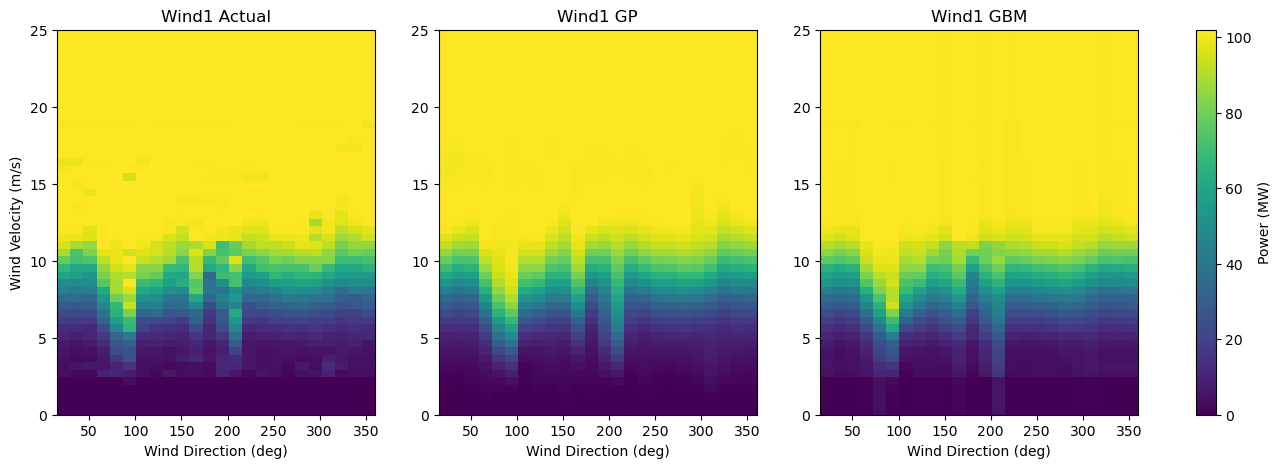

In [68]:
wind1_extent = [grids["Wind1"]["x_axis"].min(), grids["Wind1"]["x_axis"].max(),
                grids["Wind1"]["y_axis"].min(), grids["Wind1"]["y_axis"].max()]
wind1_panels = [
    ("Actual", grids["Wind1"]["power_grid"]),
    ("GP", wind1_pred_gp),
    ("GBM", wind1_pred_gbm),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, grid_) in zip(axes, wind1_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=wind1_extent, vmin=0, vmax=CAPACITY_MW["Wind1"])
    ax.set_title(f"Wind1 {title}")
    ax.set_xlabel("Wind Direction (deg)")
axes[0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/wind1_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual, computed everywhere since the grid is fully dense.

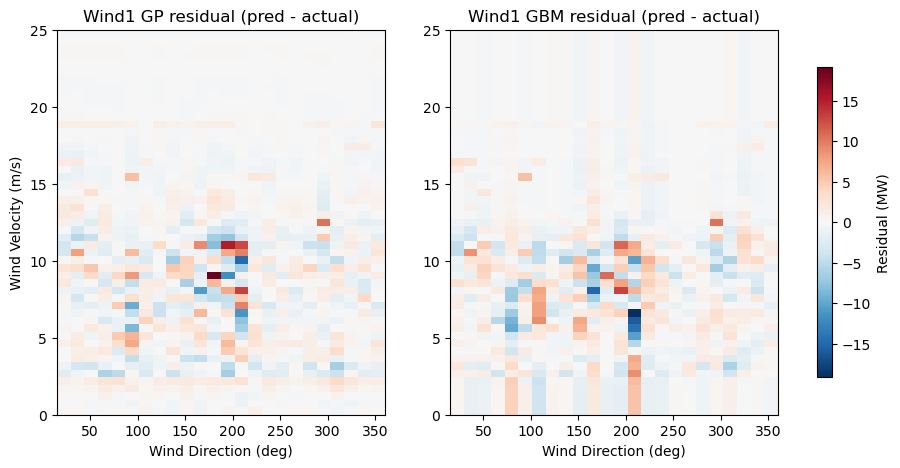

In [69]:
wind1_actual = grids["Wind1"]["power_grid"]
wind1_resid_panels = [
    ("GP", wind1_pred_gp - wind1_actual),
    ("GBM", wind1_pred_gbm - wind1_actual),
]
max_abs_resid_w1 = np.nanmax(np.abs(np.stack([r for _, r in wind1_resid_panels])))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (title, resid) in zip(axes, wind1_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=wind1_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid_w1, vmax=max_abs_resid_w1)
    ax.set_title(f"Wind1 {title} residual (pred - actual)")
    ax.set_xlabel("Wind Direction (deg)")
axes[0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/wind1_residuals.png", dpi=150)
plt.show()

### Discussion

Both models recover the expected wind power curve shape: near-zero below the roughly 2.5 m/s
cut-in speed, a steep rise through the transition band, and a flat plateau at rated capacity
(102 MW) from about 11-12 m/s onward, matching the documented cut-in/rated behavior with no
strong dependence on direction across most of the grid.

The actual grid does show a real directional feature though: a sharp power dip around
180-210 degrees in the 6-11 m/s transition band, most likely a wake or terrain effect at that
bearing. Both GP and GBM pick up the dip's presence, but neither reproduces its sharp edges
exactly, that band is where the largest residuals concentrate for both models (GP: 18.8 MW max at
9.0 m/s / 180 deg; GBM: 19.2 MW max at 6.5 m/s / 210 deg), consistent with GP's better overall CV
RMSE (2.52 MW vs. GBM's 3.11 MW) coming from being smoother everywhere else rather than from
handling this sharp local feature any better. Elsewhere the residuals are small and scattered,
so both models are reliable away from the steep transition band.

### SHAP summary

Global feature importance for the Wind1 GP and GBM models over the three input features
(`velocity`, `sin_direction`, `cos_direction`), same TreeExplainer/sampled-background approach as
the PV blocks.

In [70]:
wind1_gbm_explainer = shap.TreeExplainer(wind1_gbm_model)
wind1_gbm_shap_values = wind1_gbm_explainer.shap_values(X_wind1)
print("Wind1 GBM SHAP values shape:", wind1_gbm_shap_values.shape)

Wind1 GBM SHAP values shape: (1224, 3)


In [71]:
wind1_gp_background = shap.sample(X_wind1, 50, random_state=0)
wind1_gp_explainer = shap.Explainer(wind1_gp_model.predict, wind1_gp_background)
wind1_gp_shap_values = wind1_gp_explainer(X_wind1)
print("Wind1 GP SHAP values shape:", wind1_gp_shap_values.values.shape)

ExactExplainer explainer:  16%|█▌        | 193/1224 [00:00<?, ?it/s]

ExactExplainer explainer:  16%|█▌        | 197/1224 [00:10<00:37, 27.15it/s]

ExactExplainer explainer:  16%|█▋        | 200/1224 [00:10<00:48, 21.30it/s]

ExactExplainer explainer:  17%|█▋        | 203/1224 [00:10<00:54, 18.76it/s]

ExactExplainer explainer:  17%|█▋        | 205/1224 [00:10<00:55, 18.40it/s]

...

ExactExplainer explainer: 100%|█████████▉| 1218/1224 [01:09<00:00, 23.37it/s]

ExactExplainer explainer: 100%|█████████▉| 1221/1224 [01:09<00:00, 23.89it/s]

ExactExplainer explainer: 100%|██████████| 1224/1224 [01:09<00:00, 24.04it/s]

ExactExplainer explainer: 1225it [01:10, 14.74it/s]                          

Wind1 GP SHAP values shape: (1224, 3)


Wind1 GBM mean |SHAP|: {'velocity': np.float64(36.871), 'sin_direction': np.float64(1.797), 'cos_direction': np.float64(1.175)}
Wind1 GP mean |SHAP|: {'velocity': np.float64(33.42), 'sin_direction': np.float64(1.934), 'cos_direction': np.float64(1.964)}


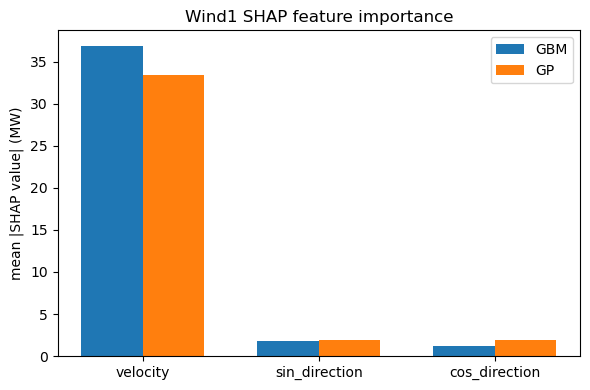

In [72]:
wind1_feature_names = ["velocity", "sin_direction", "cos_direction"]
wind1_gbm_mean_abs_shap = np.abs(wind1_gbm_shap_values).mean(axis=0)
wind1_gp_mean_abs_shap = np.abs(wind1_gp_shap_values.values).mean(axis=0)
print("Wind1 GBM mean |SHAP|:", dict(zip(wind1_feature_names, wind1_gbm_mean_abs_shap.round(3))))
print("Wind1 GP mean |SHAP|:", dict(zip(wind1_feature_names, wind1_gp_mean_abs_shap.round(3))))

x = np.arange(len(wind1_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, wind1_gbm_mean_abs_shap, width, label="GBM")
ax.bar(x + width / 2, wind1_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(wind1_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("Wind1 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/wind1_shap_summary.png", dpi=150)
plt.show()

### Discussion

Velocity dominates both models by a wide margin (GBM mean |SHAP| = 36.9 MW, GP = 33.4 MW), as
expected for an S-curve power response. The two direction components carry a small but non-zero
and roughly balanced weight (GBM: 1.8 / 1.2 MW for sin/cos; GP: 1.9 / 2.0 MW), consistent with the
localized dip seen in the response-surface figure: direction matters only in specific bearings,
not as a global effect, so its average SHAP contribution stays an order of magnitude below
velocity's even though it is locally responsible for the largest residuals.

### Standalone script export

Exports `models/wind1_model.py`, which refits both Wind1 models on import and exposes
`predict(velocity, direction, model=...)`; direction is encoded as (sin, cos) internally, same
circular treatment as in the notebook.

In [73]:
from models.wind1_model import predict as wind1_predict

for model_name in ["gp", "gbm"]:
    print(f"models/wind1_model.py predict(10, 180, model='{model_name}') = {wind1_predict(10, 180, model=model_name):.2f} MW")

models/wind1_model.py predict(10, 180, model='gp') = 71.91 MW
models/wind1_model.py predict(10, 180, model='gbm') = 68.79 MW


## Wind2 Model

Same data-driven approach as Wind1: no physics formula, GP and Gradient Boosting mapping
$(v,\ \theta)$ to power. The negative-value artifact was already clipped in the Exploratory
Data Analysis section, so `grids["Wind2"]["power_grid"]` is clean here.

### Tidy long format

Reshape the Wind2 grid to one row per (velocity, direction) cell, same as Wind1.

In [74]:
velocity_mesh_w2, direction_mesh_w2 = np.meshgrid(grids["Wind2"]["y_axis"], grids["Wind2"]["x_axis"], indexing="ij")
wind2_df = pd.DataFrame({
    "wind_velocity": velocity_mesh_w2.ravel(),
    "wind_direction": direction_mesh_w2.ravel(),
    "power": grids["Wind2"]["power_grid"].ravel(),
})
wind2_df = wind2_df.dropna(subset=["power"]).reset_index(drop=True)

In [75]:
n_rows_w2, n_cols_w2 = grids["Wind2"]["power_grid"].shape
print(f"Wind2: retained {len(wind2_df)} of {n_rows_w2 * n_cols_w2} grid cells ({n_rows_w2} velocity x {n_cols_w2} direction)")

Wind2: retained 1224 of 1224 grid cells (51 velocity x 24 direction)


### Feature matrix

Same circular direction encoding as Wind1: $(\sin\theta,\ \cos\theta)$ alongside velocity.

In [76]:
direction_rad_w2 = np.deg2rad(wind2_df["wind_direction"])
X_wind2 = np.column_stack([wind2_df["wind_velocity"], np.sin(direction_rad_w2), np.cos(direction_rad_w2)])
y_wind2 = wind2_df["power"].to_numpy()
print("Wind2 feature matrix shape:", X_wind2.shape)

Wind2 feature matrix shape: (1224, 3)


### Gaussian Process Regression

Primary model, same `make_gp_wind()` factory defined in the Wind1 block, refit here on Wind2's
tidy data.

In [77]:
wind2_gp_model = make_gp_wind().fit(X_wind2, y_wind2)
print("Wind2 GP fitted kernel:", wind2_gp_model.named_steps["gaussianprocessregressor"].kernel_)

Wind2 GP fitted kernel: 0.615**2 * RBF(length_scale=[0.579, 0.604, 0.564]) + WhiteKernel(noise_level=0.00186)


### GP cross-validation

5-fold CV $R^2$/RMSE for the Wind2 GP model, same helper and fold count as every other model.

In [78]:
r2_wind2_gp, rmse_wind2_gp = cv_evaluate(make_gp_wind, X_wind2, y_wind2)
print(f"Wind2 GP 5-fold CV: R^2 = {r2_wind2_gp.mean():.4f} +/- {r2_wind2_gp.std():.4f}, "
      f"RMSE = {rmse_wind2_gp.mean():.4f} +/- {rmse_wind2_gp.std():.4f} MW")

Wind2 GP 5-fold CV: R^2 = 0.9976 +/- 0.0008, RMSE = 1.5866 +/- 0.2079 MW


### Gradient Boosting

Secondary ML contrast, same `make_gbm()` factory defined in the Wind1 block.

In [79]:
wind2_gbm_model = make_gbm().fit(X_wind2, y_wind2)
importances_w2 = wind2_gbm_model.feature_importances_
print(f"Wind2 GBM feature importances: velocity = {importances_w2[0]:.3f}, "
      f"sin_direction = {importances_w2[1]:.3f}, cos_direction = {importances_w2[2]:.3f}")

Wind2 GBM feature importances: velocity = 0.991, sin_direction = 0.005, cos_direction = 0.003


### Gradient Boosting cross-validation

5-fold CV $R^2$/RMSE for the Wind2 GBM model, directly comparable to the GP numbers above.

In [80]:
r2_wind2_gbm, rmse_wind2_gbm = cv_evaluate(make_gbm, X_wind2, y_wind2)
print(f"Wind2 GBM 5-fold CV: R^2 = {r2_wind2_gbm.mean():.4f} +/- {r2_wind2_gbm.std():.4f}, "
      f"RMSE = {rmse_wind2_gbm.mean():.4f} +/- {rmse_wind2_gbm.std():.4f} MW")

Wind2 GBM 5-fold CV: R^2 = 0.9959 +/- 0.0011, RMSE = 2.0976 +/- 0.2073 MW


### Full-grid predictions

Predict both models over the complete native grid, same pure fit-quality check as Wind1 since
the grid is fully dense.

In [81]:
full_vel_mesh_w2, full_dir_mesh_w2 = np.meshgrid(grids["Wind2"]["y_axis"], grids["Wind2"]["x_axis"], indexing="ij")
full_dir_rad_w2 = np.deg2rad(full_dir_mesh_w2)
X_wind2_full = np.column_stack([full_vel_mesh_w2.ravel(), np.sin(full_dir_rad_w2).ravel(), np.cos(full_dir_rad_w2).ravel()])

wind2_pred_gp = wind2_gp_model.predict(X_wind2_full).reshape(full_vel_mesh_w2.shape)
wind2_pred_gbm = wind2_gbm_model.predict(X_wind2_full).reshape(full_vel_mesh_w2.shape)
print("Wind2 full-grid predictions shape:", wind2_pred_gp.shape)

Wind2 full-grid predictions shape: (51, 24)


### Response-surface heatmaps

Actual grid next to each model's full-grid prediction, same color scale and layout as the Wind1
figure, the central Wind2 figure.

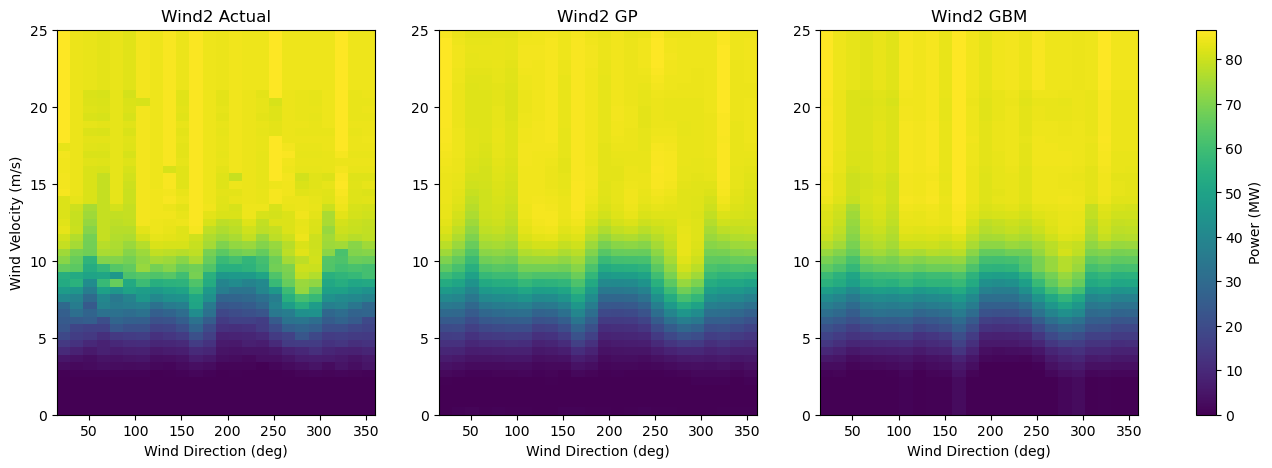

In [82]:
wind2_extent = [grids["Wind2"]["x_axis"].min(), grids["Wind2"]["x_axis"].max(),
                grids["Wind2"]["y_axis"].min(), grids["Wind2"]["y_axis"].max()]
wind2_panels = [
    ("Actual", grids["Wind2"]["power_grid"]),
    ("GP", wind2_pred_gp),
    ("GBM", wind2_pred_gbm),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, grid_) in zip(axes, wind2_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=wind2_extent, vmin=0, vmax=CAPACITY_MW["Wind2"])
    ax.set_title(f"Wind2 {title}")
    ax.set_xlabel("Wind Direction (deg)")
axes[0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/wind2_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual, computed everywhere since the grid is fully dense, same layout as the
Wind1 residual figure.

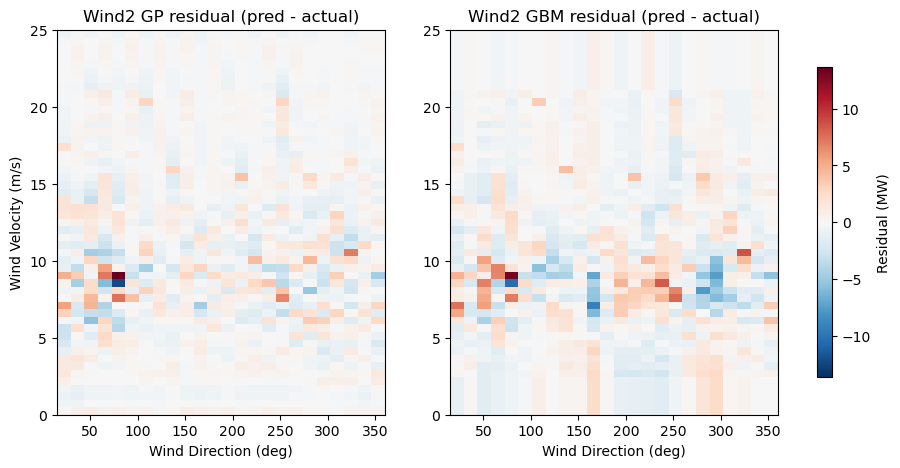

In [83]:
wind2_actual = grids["Wind2"]["power_grid"]
wind2_resid_panels = [
    ("GP", wind2_pred_gp - wind2_actual),
    ("GBM", wind2_pred_gbm - wind2_actual),
]
max_abs_resid_w2 = np.nanmax(np.abs(np.stack([r for _, r in wind2_resid_panels])))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (title, resid) in zip(axes, wind2_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=wind2_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid_w2, vmax=max_abs_resid_w2)
    ax.set_title(f"Wind2 {title} residual (pred - actual)")
    ax.set_xlabel("Wind Direction (deg)")
axes[0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/wind2_residuals.png", dpi=150)
plt.show()

### Discussion

Wind2 reproduces the same S-curve as Wind1: near-zero below roughly 3 m/s cut-in, a steep rise
through the transition band, and a flat plateau at rated capacity (86.6 MW) from about 11-13 m/s
onward. Both models fit noticeably tighter than Wind1 (GP $R^2$ = 0.9976, RMSE = 1.59 MW; GBM
$R^2$ = 0.9959, RMSE = 2.10 MW, versus Wind1's 2.52 / 3.11 MW), consistent with Wind2's smoother,
less sharply-notched actual grid.

There is still a real directional feature, a power dip around 50-90 degrees in the 7-10 m/s
transition band, and it is again where both models struggle most (GP: 13.7 MW max residual at
9.0 m/s / 75 deg; GBM: 13.1 MW max at the same cell), the same pattern as Wind1's dip at
180-210 degrees. The dip sits at a different bearing for each plant, so it is plant-specific
(consistent with a local wake or terrain effect at each site) rather than a shared physical
mechanism, elsewhere the residuals are small and scattered for both models.

### SHAP summary

Global feature importance for the Wind2 GP and GBM models, same approach as Wind1.

In [84]:
wind2_gbm_explainer = shap.TreeExplainer(wind2_gbm_model)
wind2_gbm_shap_values = wind2_gbm_explainer.shap_values(X_wind2)
print("Wind2 GBM SHAP values shape:", wind2_gbm_shap_values.shape)

Wind2 GBM SHAP values shape: (1224, 3)


In [85]:
wind2_gp_background = shap.sample(X_wind2, 50, random_state=0)
wind2_gp_explainer = shap.Explainer(wind2_gp_model.predict, wind2_gp_background)
wind2_gp_shap_values = wind2_gp_explainer(X_wind2)
print("Wind2 GP SHAP values shape:", wind2_gp_shap_values.values.shape)

ExactExplainer explainer:  16%|█▋        | 201/1224 [00:00<?, ?it/s]

ExactExplainer explainer:  17%|█▋        | 205/1224 [00:10<00:31, 32.27it/s]

ExactExplainer explainer:  17%|█▋        | 209/1224 [00:10<00:37, 27.17it/s]

ExactExplainer explainer:  17%|█▋        | 212/1224 [00:10<00:38, 25.98it/s]

ExactExplainer explainer:  18%|█▊        | 215/1224 [00:10<00:40, 25.22it/s]

...

ExactExplainer explainer:  99%|█████████▉| 1217/1224 [00:50<00:00, 24.01it/s]

ExactExplainer explainer: 100%|█████████▉| 1220/1224 [00:51<00:00, 24.82it/s]

ExactExplainer explainer: 100%|█████████▉| 1223/1224 [00:51<00:00, 24.95it/s]

ExactExplainer explainer: 1225it [00:51, 19.97it/s]                          

Wind2 GP SHAP values shape: (1224, 3)


Wind2 GBM mean |SHAP|: {'velocity': np.float64(29.595), 'sin_direction': np.float64(1.116), 'cos_direction': np.float64(0.811)}
Wind2 GP mean |SHAP|: {'velocity': np.float64(27.486), 'sin_direction': np.float64(1.359), 'cos_direction': np.float64(1.296)}


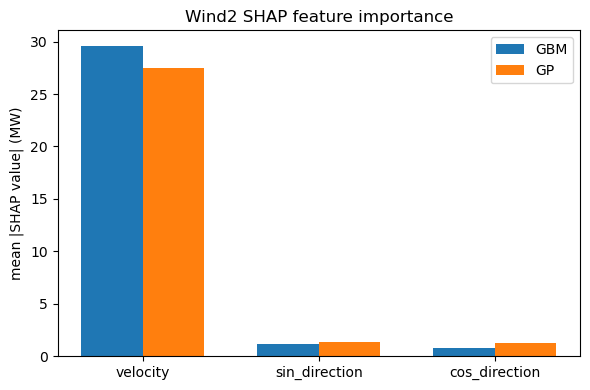

In [86]:
wind2_feature_names = ["velocity", "sin_direction", "cos_direction"]
wind2_gbm_mean_abs_shap = np.abs(wind2_gbm_shap_values).mean(axis=0)
wind2_gp_mean_abs_shap = np.abs(wind2_gp_shap_values.values).mean(axis=0)
print("Wind2 GBM mean |SHAP|:", dict(zip(wind2_feature_names, wind2_gbm_mean_abs_shap.round(3))))
print("Wind2 GP mean |SHAP|:", dict(zip(wind2_feature_names, wind2_gp_mean_abs_shap.round(3))))

x = np.arange(len(wind2_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, wind2_gbm_mean_abs_shap, width, label="GBM")
ax.bar(x + width / 2, wind2_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(wind2_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("Wind2 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/wind2_shap_summary.png", dpi=150)
plt.show()

### Discussion

Same pattern as Wind1: velocity dominates both models (GBM mean |SHAP| = 29.6 MW, GP = 27.5 MW),
with the direction components carrying a small, roughly balanced weight (GBM: 1.1 / 0.8 MW for
sin/cos; GP: 1.4 / 1.3 MW). Wind2's direction SHAP values are close to Wind1's, even though the
two plants' directional dips sit at different bearings, direction is a consistently minor but
non-zero factor for both wind plants, not something either model treats as noise.

### Standalone script export

Exports `models/wind2_model.py`, which refits both Wind2 models on import and exposes
`predict(velocity, direction, model=...)`, mirroring `models/wind1_model.py`; it also re-clips
the negative-value artifact internally so the script is correct when run standalone, without
depending on the notebook's EDA section having already run.

In [87]:
from models.wind2_model import predict as wind2_predict

for model_name in ["gp", "gbm"]:
    print(f"models/wind2_model.py predict(10, 180, model='{model_name}') = {wind2_predict(10, 180, model=model_name):.2f} MW")

models/wind2_model.py predict(10, 180, model='gp') = 66.53 MW
models/wind2_model.py predict(10, 180, model='gbm') = 66.99 MW


## Wind-combined Model

GP and Gradient Boosting fit on Wind1 and Wind2 pooled together, with plant as an added
categorical feature, mirroring the PV-combined block's approach (one-hot plant feature for the
ML models, plus a leave-one-plant-out transferability check).

### Tidy long format

Pool Wind1's and Wind2's already-tidy DataFrames, each tagged with a `plant` column.

In [88]:
wind_combined_df = pd.concat(
    [wind1_df.assign(plant="Wind1"), wind2_df.assign(plant="Wind2")],
    ignore_index=True,
)
print(f"Wind-combined: {len(wind_combined_df)} rows ({(wind_combined_df['plant'] == 'Wind1').sum()} Wind1 + "
      f"{(wind_combined_df['plant'] == 'Wind2').sum()} Wind2)")

Wind-combined: 2448 rows (1224 Wind1 + 1224 Wind2)


### Feature matrix

Velocity, $(\sin\theta,\ \cos\theta)$, and plant one-hot (`is_Wind2`), four features total.

In [89]:
is_wind2_comb = (wind_combined_df["plant"] == "Wind2").astype(float)
direction_rad_wc = np.deg2rad(wind_combined_df["wind_direction"])
X_wind_comb = np.column_stack([
    wind_combined_df["wind_velocity"], np.sin(direction_rad_wc), np.cos(direction_rad_wc), is_wind2_comb,
])
y_wind_comb = wind_combined_df["power"].to_numpy()
print("Wind-combined feature matrix shape:", X_wind_comb.shape)

Wind-combined feature matrix shape: (2448, 4)


### Gaussian Process Regression

GP on the pooled data with plant one-hot encoded as a fourth feature, so a plant boundary can
shift the surface if the two wind plants behave differently. Needs its own kernel factory since
`make_gp_wind()` is hardcoded to a 3-feature length scale.

In [90]:
def make_gp_wind_combined():
    # Same kernel structure as PV1's make_gp() (see that block for what each term means), with a
    # fourth RBF length scale added for the is_Wind2 plant feature.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF([1.0, 1.0, 1.0, 1.0], (1e-2, 1e2)) + WhiteKernel(1.0, (1e-5, 1e2))
    return make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0),
    )

wind_comb_gp_model = make_gp_wind_combined().fit(X_wind_comb, y_wind_comb)
print("Wind-combined GP fitted kernel:", wind_comb_gp_model.named_steps["gaussianprocessregressor"].kernel_)

Wind-combined GP fitted kernel: 0.562**2 * RBF(length_scale=[0.506, 0.494, 0.465, 2.43]) + WhiteKernel(noise_level=0.00248)


### GP cross-validation

5-fold CV $R^2$/RMSE for the Wind-combined GP model, same helper and fold count as every other
model.

In [91]:
r2_wind_comb_gp, rmse_wind_comb_gp = cv_evaluate(make_gp_wind_combined, X_wind_comb, y_wind_comb)
print(f"Wind-combined GP 5-fold CV: R^2 = {r2_wind_comb_gp.mean():.4f} +/- {r2_wind_comb_gp.std():.4f}, "
      f"RMSE = {rmse_wind_comb_gp.mean():.4f} +/- {rmse_wind_comb_gp.std():.4f} MW")

Wind-combined GP 5-fold CV: R^2 = 0.9970 +/- 0.0005, RMSE = 2.0731 +/- 0.1847 MW


### Gradient Boosting

GBM on the same pooled features, same `make_gbm()` factory as the Wind1/Wind2 blocks; tree splits
need no special handling for the extra categorical dimension.

In [92]:
wind_comb_gbm_model = make_gbm().fit(X_wind_comb, y_wind_comb)
importances_wc = wind_comb_gbm_model.feature_importances_
print(f"Wind-combined GBM feature importances: velocity = {importances_wc[0]:.3f}, "
      f"sin_direction = {importances_wc[1]:.3f}, cos_direction = {importances_wc[2]:.3f}, "
      f"is_Wind2 = {importances_wc[3]:.3f}")

Wind-combined GBM feature importances: velocity = 0.954, sin_direction = 0.007, cos_direction = 0.003, is_Wind2 = 0.036


### Gradient Boosting cross-validation

5-fold CV $R^2$/RMSE for the Wind-combined GBM model, directly comparable to the GP numbers
above.

In [93]:
r2_wind_comb_gbm, rmse_wind_comb_gbm = cv_evaluate(make_gbm, X_wind_comb, y_wind_comb)
print(f"Wind-combined GBM 5-fold CV: R^2 = {r2_wind_comb_gbm.mean():.4f} +/- {r2_wind_comb_gbm.std():.4f}, "
      f"RMSE = {rmse_wind_comb_gbm.mean():.4f} +/- {rmse_wind_comb_gbm.std():.4f} MW")

Wind-combined GBM 5-fold CV: R^2 = 0.9898 +/- 0.0023, RMSE = 3.7952 +/- 0.4399 MW


### Full-grid predictions

Predict over the complete native grid (Wind1 and Wind2 share the same velocity/direction axes)
twice for each model, once with `is_Wind2=0` and once with `is_Wind2=1`, so each plant's
prediction can be compared to its own actual grid.

In [94]:
full_vel_mesh_wc, full_dir_mesh_wc = np.meshgrid(grids["Wind1"]["y_axis"], grids["Wind1"]["x_axis"], indexing="ij")
full_dir_rad_wc = np.deg2rad(full_dir_mesh_wc)
X_full_wc = np.column_stack([full_vel_mesh_wc.ravel(), np.sin(full_dir_rad_wc).ravel(), np.cos(full_dir_rad_wc).ravel()])
zeros_full_wc, ones_full_wc = np.zeros(len(X_full_wc)), np.ones(len(X_full_wc))

wind_comb_pred_gp_w1 = wind_comb_gp_model.predict(np.column_stack([X_full_wc, zeros_full_wc])).reshape(full_vel_mesh_wc.shape)
wind_comb_pred_gp_w2 = wind_comb_gp_model.predict(np.column_stack([X_full_wc, ones_full_wc])).reshape(full_vel_mesh_wc.shape)
wind_comb_pred_gbm_w1 = wind_comb_gbm_model.predict(np.column_stack([X_full_wc, zeros_full_wc])).reshape(full_vel_mesh_wc.shape)
wind_comb_pred_gbm_w2 = wind_comb_gbm_model.predict(np.column_stack([X_full_wc, ones_full_wc])).reshape(full_vel_mesh_wc.shape)
print("Wind-combined full-grid predictions shape:", wind_comb_pred_gp_w1.shape)

Wind-combined full-grid predictions shape: (51, 24)


### Response-surface heatmaps

Two rows, one per plant: each plant's actual grid next to its own GP/GBM prediction (`is_Wind2`
set accordingly), the central Wind-combined figure.

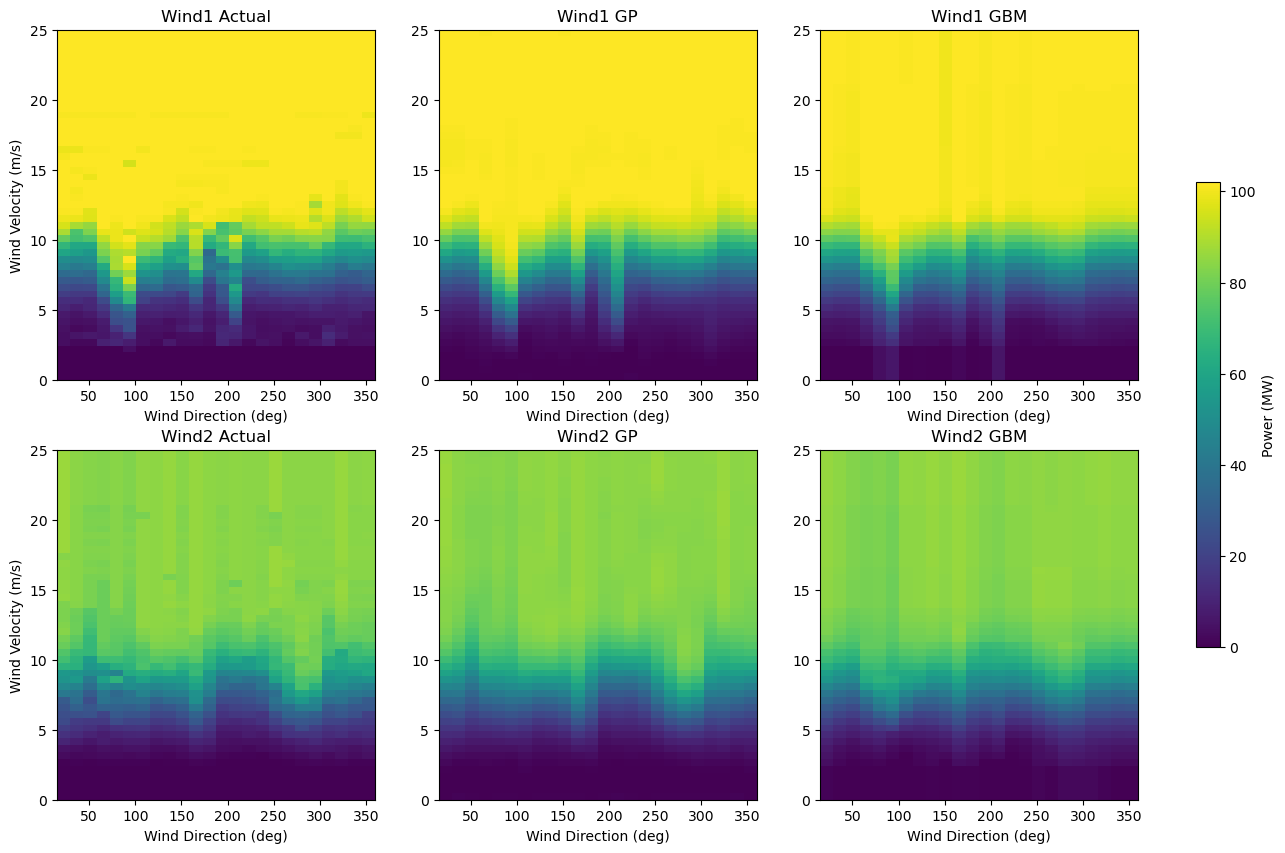

In [95]:
wind_comb_extent = [grids["Wind1"]["x_axis"].min(), grids["Wind1"]["x_axis"].max(),
                     grids["Wind1"]["y_axis"].min(), grids["Wind1"]["y_axis"].max()]
wind_comb_cap = max(CAPACITY_MW["Wind1"], CAPACITY_MW["Wind2"])
wind_comb_rows = [
    ("Wind1", grids["Wind1"]["power_grid"], wind_comb_pred_gp_w1, wind_comb_pred_gbm_w1),
    ("Wind2", grids["Wind2"]["power_grid"], wind_comb_pred_gp_w2, wind_comb_pred_gbm_w2),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (plant, actual, pred_gp, pred_gbm) in enumerate(wind_comb_rows):
    panels = [("Actual", actual), ("GP", pred_gp), ("GBM", pred_gbm)]
    for ax, (title, grid_) in zip(axes[row], panels):
        im = ax.imshow(grid_, origin="lower", aspect="auto", extent=wind_comb_extent, vmin=0, vmax=wind_comb_cap)
        ax.set_title(f"{plant} {title}")
        ax.set_xlabel("Wind Direction (deg)")
    axes[row][0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/wind_combined_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual per plant, same two-row layout as the response-surface figure above.

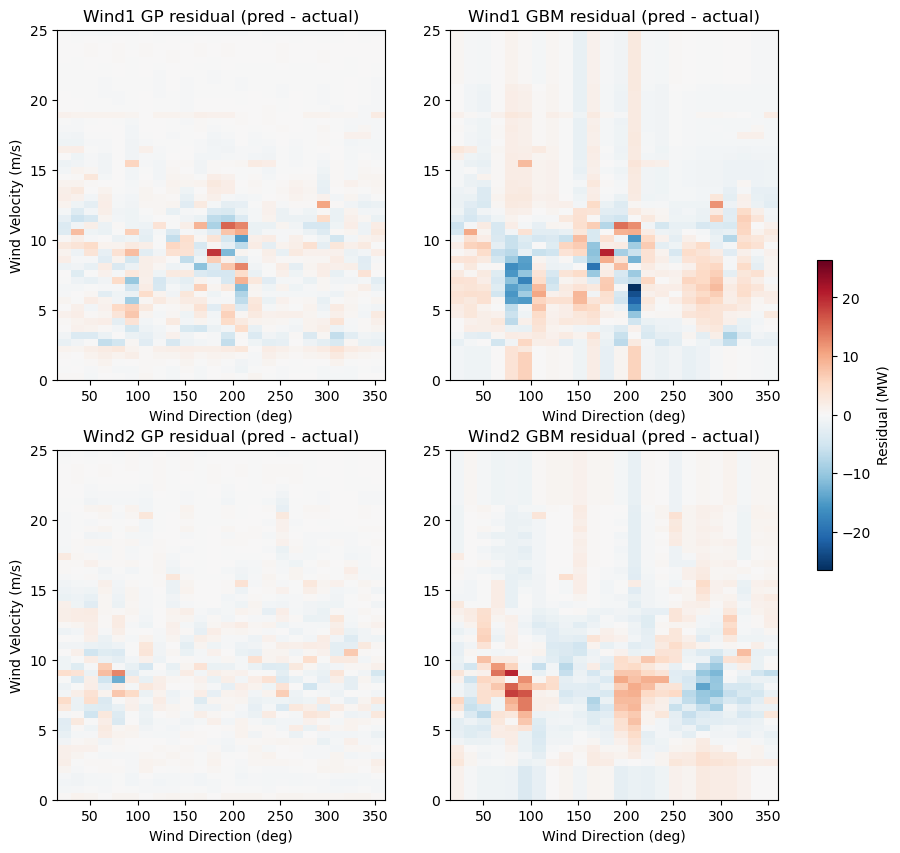

In [96]:
wind_comb_all_resid = []
for _, actual, pred_gp, pred_gbm in wind_comb_rows:
    wind_comb_all_resid += [pred_gp - actual, pred_gbm - actual]
max_abs_resid_wc = np.nanmax(np.abs(np.stack(wind_comb_all_resid)))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for row, (plant, actual, pred_gp, pred_gbm) in enumerate(wind_comb_rows):
    resid_panels = [("GP", pred_gp - actual), ("GBM", pred_gbm - actual)]
    for ax, (title, resid) in zip(axes[row], resid_panels):
        im = ax.imshow(resid, origin="lower", aspect="auto", extent=wind_comb_extent,
                        cmap="RdBu_r", vmin=-max_abs_resid_wc, vmax=max_abs_resid_wc)
        ax.set_title(f"{plant} {title} residual (pred - actual)")
        ax.set_xlabel("Wind Direction (deg)")
    axes[row][0].set_ylabel("Wind Velocity (m/s)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/wind_combined_residuals.png", dpi=150)
plt.show()

### Discussion

Both models correctly separate the two plants' distinct rated capacities (102 MW for Wind1,
86.6 MW for Wind2) and each plant's own directional dip (Wind1's near 90-100 deg, Wind2's near
50-90 deg), so the `is_Wind2` feature is doing real work, not just adding noise.

GP handles the pooling gracefully: its worst-case residuals barely move from the standalone
numbers (Wind1: 18.9 MW here vs. 18.8 MW standalone; Wind2: 13.0 MW vs. 13.7 MW). GBM does not,
its worst-case residuals get noticeably larger under pooling (Wind1: 26.4 MW here vs. 19.2 MW
standalone; Wind2: 20.1 MW vs. 13.1 MW), both still concentrated at each plant's own transition-
band dip. A single set of GBM trees splitting on a shared feature space, direction dips at
different bearings for the two plants, appears less able to keep each plant's sharp local feature
separate than GP's smooth per-feature length scales combined with the plant dummy. For this
project, GP is the safer choice for the pooled wind model if the transition-band dip region
matters for downstream use.

### SHAP summary

Global feature importance for the Wind-combined GP and GBM models over all four features
(`velocity`, `sin_direction`, `cos_direction`, `is_Wind2`), same approach as the PV-combined
block.

In [97]:
wind_comb_gbm_explainer = shap.TreeExplainer(wind_comb_gbm_model)
wind_comb_gbm_shap_values = wind_comb_gbm_explainer.shap_values(X_wind_comb)
print("Wind-combined GBM SHAP values shape:", wind_comb_gbm_shap_values.shape)

Wind-combined GBM SHAP values shape: (2448, 4)


In [98]:
wind_comb_gp_background = shap.sample(X_wind_comb, 50, random_state=0)
wind_comb_gp_explainer = shap.Explainer(wind_comb_gp_model.predict, wind_comb_gp_background)
wind_comb_gp_shap_values = wind_comb_gp_explainer(X_wind_comb)
print("Wind-combined GP SHAP values shape:", wind_comb_gp_shap_values.values.shape)

ExactExplainer explainer:   4%|▍         | 94/2448 [00:00<?, ?it/s]

ExactExplainer explainer:   4%|▍         | 96/2448 [00:10<02:22, 16.56it/s]

ExactExplainer explainer:   4%|▍         | 98/2448 [00:10<04:35,  8.52it/s]

ExactExplainer explainer:   4%|▍         | 100/2448 [00:10<04:36,  8.50it/s]

ExactExplainer explainer:   4%|▍         | 101/2448 [00:10<04:42,  8.30it/s]

...

ExactExplainer explainer: 100%|█████████▉| 2447/2448 [04:50<00:00,  8.69it/s]

ExactExplainer explainer: 100%|██████████| 2448/2448 [04:50<00:00,  8.71it/s]

ExactExplainer explainer: 2449it [04:50,  8.53it/s]                          

ExactExplainer explainer: 2449it [04:50,  8.10it/s]

Wind-combined GP SHAP values shape: (2448, 4)


Wind-combined GBM mean |SHAP|: {'velocity': np.float64(33.205), 'sin_direction': np.float64(1.117), 'cos_direction': np.float64(0.903), 'is_Wind2': np.float64(5.82)}
Wind-combined GP mean |SHAP|: {'velocity': np.float64(31.829), 'sin_direction': np.float64(1.684), 'cos_direction': np.float64(1.977), 'is_Wind2': np.float64(4.964)}


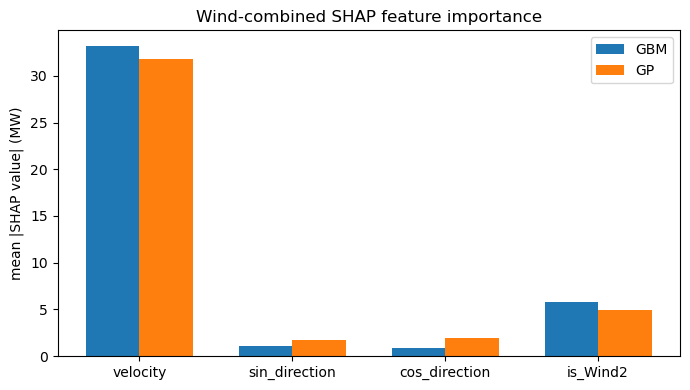

In [99]:
wind_comb_feature_names = ["velocity", "sin_direction", "cos_direction", "is_Wind2"]
wind_comb_gbm_mean_abs_shap = np.abs(wind_comb_gbm_shap_values).mean(axis=0)
wind_comb_gp_mean_abs_shap = np.abs(wind_comb_gp_shap_values.values).mean(axis=0)
print("Wind-combined GBM mean |SHAP|:", dict(zip(wind_comb_feature_names, wind_comb_gbm_mean_abs_shap.round(3))))
print("Wind-combined GP mean |SHAP|:", dict(zip(wind_comb_feature_names, wind_comb_gp_mean_abs_shap.round(3))))

x = np.arange(len(wind_comb_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, wind_comb_gbm_mean_abs_shap, width, label="GBM")
ax.bar(x + width / 2, wind_comb_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(wind_comb_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("Wind-combined SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/wind_combined_shap_summary.png", dpi=150)
plt.show()

### Discussion

Velocity still dominates overwhelmingly (GBM = 33.2 MW, GP = 31.8 MW), but plant identity now
outweighs both direction components, same pattern as the PV-combined block: `is_Wind2` scores
5.8 MW (GBM) and 5.0 MW (GP), versus 0.9-1.7 MW for `sin_direction`/`cos_direction`. That matches
the response-surface figure directly, the two plants differ in rated capacity (102 vs. 86.6 MW)
and dip location, a bigger and more consistent signal across the whole grid than direction, which
only matters locally near each plant's own transition-band dip.

### Leave-one-plant-out transferability check

Train each model on one wind plant's cells only and test on the other's, in both directions,
same transferability stress test as the PV-combined block. Trains on raw
`[velocity, sin_direction, cos_direction]` with no `is_Wind2` feature, since the training plant
is constant within each direction.

In [100]:
for train_name, test_name in [("Wind1", "Wind2"), ("Wind2", "Wind1")]:
    train_df = wind1_df if train_name == "Wind1" else wind2_df
    test_df = wind1_df if test_name == "Wind1" else wind2_df
    train_dir_rad = np.deg2rad(train_df["wind_direction"])
    test_dir_rad = np.deg2rad(test_df["wind_direction"])
    X_train = np.column_stack([train_df["wind_velocity"], np.sin(train_dir_rad), np.cos(train_dir_rad)])
    X_test = np.column_stack([test_df["wind_velocity"], np.sin(test_dir_rad), np.cos(test_dir_rad)])
    y_train, y_test = train_df["power"].to_numpy(), test_df["power"].to_numpy()

    model = make_gp_wind().fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"GP trained on {train_name}, tested on {test_name}: R^2 = {r2:.4f}, RMSE = {rmse:.4f} MW")

GP trained on Wind1, tested on Wind2: R^2 = 0.7801, RMSE = 15.6104 MW


GP trained on Wind2, tested on Wind1: R^2 = 0.8539, RMSE = 15.7221 MW


In [101]:
for train_name, test_name in [("Wind1", "Wind2"), ("Wind2", "Wind1")]:
    train_df = wind1_df if train_name == "Wind1" else wind2_df
    test_df = wind1_df if test_name == "Wind1" else wind2_df
    train_dir_rad = np.deg2rad(train_df["wind_direction"])
    test_dir_rad = np.deg2rad(test_df["wind_direction"])
    X_train = np.column_stack([train_df["wind_velocity"], np.sin(train_dir_rad), np.cos(train_dir_rad)])
    X_test = np.column_stack([test_df["wind_velocity"], np.sin(test_dir_rad), np.cos(test_dir_rad)])
    y_train, y_test = train_df["power"].to_numpy(), test_df["power"].to_numpy()

    model = make_gbm().fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"GBM trained on {train_name}, tested on {test_name}: R^2 = {r2:.4f}, RMSE = {rmse:.4f} MW")

GBM trained on Wind1, tested on Wind2: R^2 = 0.7818, RMSE = 15.5485 MW


GBM trained on Wind2, tested on Wind1: R^2 = 0.8547, RMSE = 15.6784 MW


### Discussion

Both models degrade sharply on a completely unseen plant, RMSE rises to about 15.5-15.7 MW,
roughly six to eight times the pooled-with-both-plants-seen numbers (GP 2.1 MW, GBM 3.8 MW) and
well above even the weaker standalone within-plant CV numbers (2.1-3.8 MW). Unlike the PV-combined
check, there is no ranking flip here, GP ($R^2$ = 0.78-0.85) and GBM ($R^2$ = 0.78-0.85) perform
almost identically under LOPO, both losing the same ground.

This makes physical sense: Wind1 and Wind2 differ in both rated capacity (102 vs. 86.6 MW) and
transition-band dip location, so a model trained on one plant has no way to know the other
plant's capacity ceiling or where its dip sits, no physics formula's smaller degrees of freedom
to fall back on here, since neither wind model has one. The practical takeaway matches the PV
block: pooling is worth doing when both plants have data (both models benefit, GP especially),
but neither model should be trusted to extrapolate to a wind plant it has never seen data from.

### Standalone script export

Exports `models/wind_combined_model.py`, which refits both models on import and exposes
`predict(velocity, direction, plant, model=...)`, mirroring `models/pv_combined_model.py`'s
interface; it re-clips the Wind2 negative-value artifact internally so the script is correct when
run standalone.

In [102]:
from models.wind_combined_model import predict as wind_combined_predict

for plant in ["Wind1", "Wind2"]:
    for model_name in ["gp", "gbm"]:
        pred = wind_combined_predict(10, 180, plant=plant, model=model_name)
        print(f"models/wind_combined_model.py predict(10, 180, plant='{plant}', model='{model_name}') = {pred:.2f} MW")

models/wind_combined_model.py predict(10, 180, plant='Wind1', model='gp') = 71.83 MW
models/wind_combined_model.py predict(10, 180, plant='Wind1', model='gbm') = 72.24 MW
models/wind_combined_model.py predict(10, 180, plant='Wind2', model='gp') = 65.86 MW
models/wind_combined_model.py predict(10, 180, plant='Wind2', model='gbm') = 64.25 MW


## Cross-Model Comparison

Pulls together the 5-fold CV $R^2$/RMSE from all six model blocks, the physics-vs-ML divergence
in the unsampled PV region, and the pooling-helps-or-hurts verdict from the two
leave-one-plant-out checks.

### $R^2$/RMSE summary table

Every model's 5-fold CV numbers, collected from the printed output of each model block above (not
recomputed here) into one table for direct comparison.

In [103]:
comparison_rows = [
    ("PV1", "Physics", 0.9383, 5.2506),
    ("PV1", "GP", 0.9860, 2.5368),
    ("PV1", "RF", 0.9890, 2.2466),
    ("PV2", "Physics", 0.9722, 3.4112),
    ("PV2", "GP", 0.9961, 1.2715),
    ("PV2", "RF", 0.9935, 1.6397),
    ("PV-combined", "Physics", 0.9441, 5.1009),
    ("PV-combined", "GP", 0.9920, 1.9206),
    ("PV-combined", "RF", 0.9911, 2.0304),
    ("Wind1", "GP", 0.9962, 2.5190),
    ("Wind1", "GBM", 0.9941, 3.1102),
    ("Wind2", "GP", 0.9976, 1.5866),
    ("Wind2", "GBM", 0.9959, 2.0976),
    ("Wind-combined", "GP", 0.9970, 2.0731),
    ("Wind-combined", "GBM", 0.9898, 3.7952),
]
comparison_df = pd.DataFrame(comparison_rows, columns=["Model", "Method", "R2", "RMSE_MW"])
print(comparison_df.to_string(index=False))

        Model  Method     R2  RMSE_MW
          PV1 Physics 0.9383   5.2506
          PV1      GP 0.9860   2.5368
          PV1      RF 0.9890   2.2466
          PV2 Physics 0.9722   3.4112
          PV2      GP 0.9961   1.2715
          PV2      RF 0.9935   1.6397
  PV-combined Physics 0.9441   5.1009
  PV-combined      GP 0.9920   1.9206
  PV-combined      RF 0.9911   2.0304
        Wind1      GP 0.9962   2.5190
        Wind1     GBM 0.9941   3.1102
        Wind2      GP 0.9976   1.5866
        Wind2     GBM 0.9959   2.0976
Wind-combined      GP 0.9970   2.0731
Wind-combined     GBM 0.9898   3.7952


### Leave-one-plant-out summary table

Both combined models' transferability numbers side by side.

In [104]:
lopo_rows = [
    ("PV-combined", "Physics", "PV1->PV2", 0.9207, 5.8346),
    ("PV-combined", "Physics", "PV2->PV1", 0.8875, 7.2429),
    ("PV-combined", "GP", "PV1->PV2", 0.8881, 6.9334),
    ("PV-combined", "GP", "PV2->PV1", 0.8605, 8.0653),
    ("PV-combined", "RF", "PV1->PV2", 0.8828, 7.0939),
    ("PV-combined", "RF", "PV2->PV1", 0.8897, 7.1691),
    ("Wind-combined", "GP", "Wind1->Wind2", 0.7801, 15.6104),
    ("Wind-combined", "GP", "Wind2->Wind1", 0.8539, 15.7221),
    ("Wind-combined", "GBM", "Wind1->Wind2", 0.7818, 15.5485),
    ("Wind-combined", "GBM", "Wind2->Wind1", 0.8547, 15.6784),
]
lopo_df = pd.DataFrame(lopo_rows, columns=["Model", "Method", "Direction", "R2", "RMSE_MW"])
print(lopo_df.to_string(index=False))

        Model  Method    Direction     R2  RMSE_MW
  PV-combined Physics     PV1->PV2 0.9207   5.8346
  PV-combined Physics     PV2->PV1 0.8875   7.2429
  PV-combined      GP     PV1->PV2 0.8881   6.9334
  PV-combined      GP     PV2->PV1 0.8605   8.0653
  PV-combined      RF     PV1->PV2 0.8828   7.0939
  PV-combined      RF     PV2->PV1 0.8897   7.1691
Wind-combined      GP Wind1->Wind2 0.7801  15.6104
Wind-combined      GP Wind2->Wind1 0.8539  15.7221
Wind-combined     GBM Wind1->Wind2 0.7818  15.5485
Wind-combined     GBM Wind2->Wind1 0.8547  15.6784


### Discussion

Across all six model blocks, GP is the strongest or near-strongest performer by CV RMSE (0.9860 to
0.9976 $R^2$ everywhere it is fit), and the tree ensembles (RF for PV, GBM for wind) trail it by a
small, consistent margin. The physics formula is the weakest fit for every PV model (RMSE 3.4 to
5.3 MW versus 1.3 to 2.5 MW for GP/RF), but weak within-plant fit is not the same as weak
usefulness, its two coefficients are directly interpretable and it degrades more gracefully than
the ML models do when asked to extrapolate, which is the more important property for the unsampled
PV region.

That extrapolation gap is the central physics-vs-ML finding: the physics formula's raw linear
form has no saturation term, so it climbs past nameplate capacity in a meaningful share of
unsampled cells in every PV block (PV1: 24.8%, PV2: 13.7%, PV-combined: 20.6% for PV1's unsampled
cells and 23.3% for PV2's), peaking as high as 96.4 MW against a 75 MW nameplate. GP and RF never
do this, both stay at or under the observed maximum by construction in every PV block, so for
dispatch estimates that must respect the capacity cap, the ML models are the safer choice in the
unsampled region even though the physics formula fits the sampled region less tightly.

The two leave-one-plant-out checks answer the "does pooling help or hurt" question directly:
pooling helps whenever both plants contribute training data, GP and RF/GBM's pooled CV numbers
sit close to or better than their weaker standalone plant in every combined block, so there is no
real cost to pooling. But zero-shot transfer to a plant with no training data at all is unreliable
across the board, RMSE roughly doubles to triples versus the pooled numbers in both the PV and
wind combined blocks. The one place the two domains diverge: PV's physics formula generalizes
better than GP/RF under this stress test ($R^2$ = 0.89-0.92 vs. 0.86-0.89), while wind has no such
fallback, GP and GBM degrade by almost identical amounts since neither has a simpler form to lean
on. The practical rule for this project: pool when you can, but do not trust any of these six
models, physics included, to extrapolate to a plant they have never seen data from.

## Limitations & Future Work

Every model in this notebook is fit on the source spreadsheet's aggregated power-curve grids, not
raw plant telemetry: 298 sampled cells for PV1, 268 for PV2, and 1224 fully-dense cells each for
Wind1 and Wind2. That is enough to build and validate a complete pipeline end to end, grid
parsing, physics and ML fits, cross-validation, response-surface diagnostics, SHAP explanations,
and deployable `predict()` scripts for all six models, but it is a small, coarsely-binned dataset
by machine-learning standards, and every finding above should be read with that in mind. This
notebook is best read as a proof of concept: it demonstrates the modeling approach works and
surfaces real, actionable findings (the PV extrapolation risk, the pooling-helps-but-does-not-
transfer result) on the data available today, not a finished production model.

With richer data, several concrete improvements become possible:

- **Raw time-series SCADA/telemetry** (minute- or hour-resolution measurements instead of
  aggregated bins) would support far richer features, ramp rates, temperature history, air
  density and turbulence intensity for wind, soiling and spectral effects for PV, and would turn
  the current grid-cell regression into a proper time-series problem with far more training rows.
- **Denser sampling of the PV input space**, especially the physically-decoupled corners that are
  currently unsampled, would let the ML models learn that region directly instead of needing to
  extrapolate into it blindly, which is the root cause of the physics-vs-ML divergence documented
  in the PV sections above.
- **More plants per technology** would directly address the leave-one-plant-out generalization
  gap: the transferability check in this notebook is necessarily an $n=2$ comparison per
  technology, and a model's ability to generalize to a genuinely new plant can only be tested with
  more than one held-out example.
- **More data overall** would make more expressive models viable without the overfitting risk that
  currently rules them out at this sample size (deeper GP kernels, ensemble stacking, neural
  approaches), and would make the GP's predictive uncertainty estimates more trustworthy for
  operational use.

None of this blocks using the current models as-is for their intended purpose, understanding the
shape of each plant's power curve and getting a defensible estimate in the sampled region, it
defines the roadmap for turning this proof of concept into a production-grade forecasting tool.

## Lessons

- The source grids use merged/positional headers, not real pandas headers. `pd.read_excel`'s
  auto-detected "Unnamed: N" columns are the numeric axis values misread as headers, always parse
  these sheets by position, never trust the auto-detected header row.
- The PV "missing values" are a sampling artifact of physically coupled inputs (irradiance heats
  the module, so cold-module/high-irradiance and hot-module/low-irradiance combinations barely
  occur), not a data-quality issue. Say this explicitly wherever the missingness is shown so a
  reader does not mistake it for something to fix in the source data.
- GroupKFold and the usual split-before-derivation concerns from labeled classification/ML
  projects do not apply to aggregated grid-cell regression, these are already-aggregated bin
  statistics, not raw repeated measurements. Plain k-fold is the right tool here, and the
  leave-one-plant-out check (not cross-validation) is what actually stress-tests generalization
  in this project.
- Report specific RMSE/$R^2$ numbers per model, never vague qualitative claims like "performs
  well". Every discussion cell in this notebook cites the exact figures the reader can trace back
  to the printed CV output above it.
- A feature-space mismatch is easy to introduce silently when a variable name is reused across
  purposes. The PV1 GP/RF cells were originally fit on the physics formula's transformed features
  ($[G, G(T_m-25)]$) by reusing the `X_pv1` variable, then predicted on raw $[G, T_m]$ at full-grid
  time, a train/predict mismatch that produced smooth-looking but wrong response surfaces (flat,
  near-horizontal bands with almost no temperature dependence) until it was caught and fixed by
  comparing against the independently-written standalone script, which had the raw features right
  from the start. When two code paths compute "the same thing" two different ways, that
  disagreement is a cheap and effective correctness check.
- Circular features (wind direction) need explicit $(\sin\theta,\ \cos\theta)$ encoding before
  going into a distance-based model like GP; raw degrees put $15^\circ$ and $360^\circ$ at
  opposite ends of the feature space even though they are adjacent bearings.
- Verify the actual dataset shape (grid dimensions, fill rate, row counts after `dropna`) before
  trusting planning-stage assumptions, and re-verify after every append, since the notebook state
  can change between sessions.
- The author line was confirmed with Erick before the title cell was written, and `data/` files
  (including `FPCs.xlsm` itself) are never named in any committed deliverable, both are treated as
  fixed constraints throughout, not just at the start.

## References

[1] D.L. King, J.A. Kratochvil, W.E. Boyson, "Temperature Coefficients for PV Modules and Arrays:
Measurement Methods, Difficulties, and Results," Proc. 26th IEEE Photovoltaic Specialists
Conference, Anaheim, CA, Sept 29-Oct 3 1997, pp. 1183-1186, DOI: 10.1109/PVSC.1997.654300.